# Assignment 1 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
2. [Dataset Description](#2-dataset-description)
   - 2.1. [Data Provenance](#21-data-provenance)
   - 2.2. [Data Structure](#21-data-structure)
   - 2.3. [Class Labels](#22-class-labels)
   - 2.4. [Dataset Size](#23-dataset-size)
   - 2.5. [Dataset Characteristics and Challenges](#24-dataset-characteristics-and-challenges)

3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
   - 3.1. [Data Loading and Initial Inspection](#31-data-loading-and-initial-inspection)
   - 3.2. [Class Distribution Analysis](#32-class-distribution-analysis)
   - 3.3. [Text Length and Complexity Analysis](#33-text-length-and-complexity-analysis)
   - 3.4. [Linguistic Content Analysis (N-grams)](#34-linguistic-content-analysis-n-grams)
   - 3.5. [Special Character & Punctuation Density](#35-special-character--punctuation-density)
   - 3.6. [Vocabulary Richness (Lexical Diversity)](#36-vocabulary-richness-lexical-diversity)

4. [Text Preprocessing](#4-text-preprocessing)
   - 4.1. [Data Loading and Initial Cleaning](#41-data-loading-and-initial-cleaning)
   - 4.2. [Meta-Feature Extraction and Text Normalization](#42-meta-feature-extraction-and-text-normalization)
   - 4.3. [Tokenization and Stopword Removal](#43-tokenization-and-stopword-removal)
   - 4.4. [Lemmatization](#44-lemmatization)

5. [Feature Representation](#5-feature-representation)
   - 5.1. [TF-IDF (Term Frequency-Inverse Document Frequency)](#51-tf-idf-term-frequency-inverse-document-frequency)
   - 5.2. [Word2Vec](#52-word2vec)
      - 5.2.1. [Logistic Regression (Standard)](#521-logistic-regression-standard)
      - 5.2.2. [Multi-layer Perceptron (Standard)](#522-multi-layer-perceptron-standard)
      - 5.2.3. [Logistic Regression (Weighted)](#523-logistic-regression-weighted)
      - 5.2.4. [Multi-layer Perceptron (Weighted)](#524-multi-layer-perceptron-weighted)
      - 5.2.5. [Word2Vec Performance and Interpretation](#525-word2vec-performance-and-interpretation)

6. [Baseline Model & Data Splitting](#6-baseline-model--data-splitting)
   - 6.1. [Train-Test Split](#61-train-test-split)
   - 6.2. [The Baseline Model](#62-the-baseline-model)

7. [Classification Models](#7-classification-models)
   - 7.1. [Logistic Regression (Standard)](#71-logistic-regression-standard)
   - 7.2. [Random Forest (Standard)](#72-random-forest-standard)
   - 7.3. [Support Vector Machine (Standard)](#73-support-vector-machine-standard)
   - 7.4. [Multi-Layer Perceptron (Standard)](#74-multi-layer-perceptron-standard)
   - 7.5. [Comparison of Standard Models](#75-comparison-of-standard-models)

8. [Addressing Class Imbalance: Cost-Sensitive Learning via Class Weights](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)
   - 8.1. [Logistic Regression (with Weights)](#81-logistic-regression-with-weights)
   - 8.2. [Multi-Layer Perceptron (with Weights)](#82-multi-layer-perceptron-with-weights)
   - 8.3. [Multi-Layer Perceptron Fine-Tuning (Optuna)](#83-multi-layer-perceptron-fine-tuning-optuna)
   - 8.4. [Comparison: Standard vs. Cost-Sensitive Models](#84-comparison-standard-vs-cost-sensitive-models)
   - 8.5. [Comparison: TF-IDF vs Word2Vec](#85-comparison-tf-idf-vs-word2vec)

9. [Error Analysis: Investigating Model Blind Spots](#9-error-analysis-investigating-model-blind-spots)

10. [Discussion/Conclusion](#10-discussionconclusion)

11. [Related Work](#11-related-work)

12. [References](#12-references)

### 1. Introduction
[[go back to the top]](#table-of-contents)

Text classification remains a fundamental task in Natural Language Processing (NLP), as it enables computers to automatically understand and organize large amounts of textual data. It plays a key role in security-related applications, such as detecting fraudulent messages, identifying phishing attempts, and filtering unwanted or harmful communications.

This project focuses on classifying emails into three categories: **Ham**, **Spam**, and **Phishing**. As phishing attacks become more sophisticated and increasingly resemble legitimate messages, it is essential to develop reliable traditional machine learning classifiers that can detect them efficiently. Such approaches are particularly valuable because they offer fast predictions and can be deployed in real-world systems where low latency and reliability are critical.

The objective of this assignment is to design, implement, and evaluate a complete NLP pipeline using a large-scale dataset of over 365000 emails. Unlike traditional spam detection, which usually focuses on a simple binary distinction, this task is more challenging because it requires separating phishing emails from regular spam and legitimate messages. Phishing emails are often carefully crafted to appear trustworthy, making them harder to detect. To address this challenge, we explore different feature representation techniques, including sparse methods such as TF-IDF and dense representations based on word embeddings. These features are then used with traditional machine learning classifiers, including Naive Bayes, Logistic Regression, Random Forest, Support Vector Machines (SVM), and Multi-layer Perceptron (MLP), allowing us to evaluate their effectiveness in accurately identifying each email category.

This report documents the entire development process, including:

- **Exploratory Data Analysis (EDA):** Identifying class imbalances and linguistic patterns.

- **Pre-processing & Feature Engineering:** Justifying the selection of Sparse (TF-IDF) vs Dense (Word2Vec) representations and implementing Cost-Sensitive Learning to mitigate class imbalance.

- **Model Evaluation:** A systematic comparison of classifiers using Precision, Recall, and Macro-F1 metrics.

- **Error Analysis:** A qualitative assessment of misclassified instances to identify model limitations.

By comparing different feature representations and machine learning models, this project aims to better understand how traditional ML techniques perform when applied to large-scale, real-world security datasets. This analysis helps highlight the strengths and limitations of each approach, providing insight into which combinations of features and classifiers are most effective for detecting spam and phishing in modern communication systems.


### 2. Dataset Description
[[go back to the top]](#table-of-contents)


#### 2.1. Data Provenance
[[go back to the topic]](#2-dataset-description)

The dataset used in this work is a secondary, large-scale aggregated collection obtained from Kaggle [[The Biggest Spam Ham Phish Email Dataset]](https://www.kaggle.com/datasets/akshatsharma2/the-biggest-spam-ham-phish-email-dataset-300000). According to the dataset provider, it was constructed by compiling multiple publicly available and open-source datasets into a single standardized format. 

The exact sources included in this aggregation are not fully documented. However, based on inspection of the data, it is clear that it combines content from different origins:
- **Ham (Legitimate Emails):** Visibly sourced from the Enron Email Corpus, which contains real corporate communications from Enron employees before 2001.
- **Spam and Phishing:** Compiled from unspecified open-source cybersecurity honeypots and public message classification benchmarks.

The labels in this dataset were not manually reviewed or annotated for this specific version. Instead, they were inherited from the original sources. For example, emails captured by automated systems like honeypots are directly labeled as spam or phishing. As a result, the labeling process is deterministic and depends on prior classifications. All samples consist of English-language email text, representing real-world digital communication.

#### 2.2. Dataset Structure
[[go back to the topic]](#2-dataset-description)

The dataset consists of two main columns:

- **text**: contains the raw email content. This includes the body of the message and may contain informal language, formatting artifacts, or domain-specific vocabulary.
- **label**: contains the numerical class assigned to each email, representing its category.

Each row corresponds to a single email instance and its associated label.

#### 2.3. Class Labels
[[go back to the topic]](#2-dataset-description)

The classification task is a multi-class problem with three categories:

- **0 — Ham**: legitimate, non-malicious emails  
- **1 — Phish**: malicious emails designed to deceive users and steal sensitive information  
- **2 — Spam**: unsolicited or irrelevant commercial or bulk emails  

This distinction is particularly important because phishing emails often closely resemble legitimate communication, making them more difficult to detect than traditional spam.


#### 2.4. Dataset Size
[[go back to the topic]](#2-dataset-description)

The dataset contains:

- **Total samples:** 365448 emails  
- **Number of classes:** 3  
- **Task type:** Multi-class text classification  
- **Language:** English  

The large size of the dataset makes it suitable for training and evaluating robust machine learning models and enables meaningful comparisons between different feature representations and classifiers.


#### 2.5. Dataset Characteristics and Challenges
[[go back to the topic]](#2-dataset-description)

This dataset presents several challenges typical of real-world NLP classification problems:

- High vocabulary diversity  
- Class overlap between phishing and legitimate emails (Phishing emails are designed to mimic Ham, making simple keyword detection insufficient.) 
- Informal and inconsistent text formatting  
- Potential class imbalance  
- Scalability (With over 365000 samples, creating a sparse feature matrix (like TF-IDF) requires careful memory management and feature selection (e.g., limiting max_features) to remain computationally feasible on a standard machine without using Deep Learning.)

These characteristics make the dataset a realistic benchmark for evaluating traditional machine learning approaches to email security and automated text classification.

### 3. Exploratory Data Analysis (EDA)
[[go back to the top]](#table-of-contents)

Before diving into preprocessing and model training, it is crucial to understand the underlying structure and characteristics of our dataset. Exploratory Data Analysis (EDA) allows us to identify patterns, detect potential anomalies (such as empty messages), and quantify the distribution of our target classes.

In this section, we focus on three main aspects:

- **Class Distribution:** To determine if the dataset is balanced or if certain categories (like Phishing) are underrepresented.

- **Message Length Analysis:** To see if the number of words or characters differs significantly between legitimate emails and malicious ones.

- **Data Integrity:** Identifying missing values or duplicates that could bias the model's performance.

Understanding these factors is essential for choosing the right evaluation metrics (e.g., Accuracy vs. Macro-F1) and for justifying our preprocessing decisions.

#### Imports

In [1]:
# Standard Library
import os
import re
import string
import random
import copy

# Data Manipulation & Computation
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec

# Utilities & Hyperparameter Tuning
import joblib
import optuna
from tqdm import tqdm

# Machine Learning (Scikit-Learn)
# Preprocessing & Selection
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

# Tool Configurations
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 3.1. Data Loading and Initial Inspection
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In [2]:
# Load the dataset
df = pd.read_csv('data/df.csv')

# 1. Dataset Dimensions
rows, cols = df.shape
print(f"Dataset Shape: {rows} rows and {cols} columns")

# 2. Alignment Check: Does every row have a label?
# We check if the number of labels matches the number of rows
total_labels = df['label'].count()
print(f"Total number of labels: {total_labels}")

if rows == total_labels:
    print("Verification Successful: Every row has an associated label.")
else:
    print(f"Warning: Integrity issue! {rows - total_labels} rows are missing a label.")

# 3. Text-Label Integrity (Missing values)
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing)

# 4. Basic Inspection of the first rows
print("\nFirst few rows of the dataset:")
print(df.head())

# 5. Numerical distribution of labels
print("\nNumerical distribution of labels:")
print(df['label'].value_counts())

Dataset Shape: 365448 rows and 2 columns
Total number of labels: 365448
Verification Successful: Every row has an associated label.

Missing values per column:
label    0
text     2
dtype: int64

First few rows of the dataset:
   label                                               text
0      0  wrong bill grace i ' ll forward original messa...
1      0  i have continued the hilcorp old ocean deal da...
2      0  several related issues have resulted in an inc...
3      0  one year rate for this one will be escapenumbe...
4      0  attached is the weekly deal report for escapen...

Numerical distribution of labels:
label
0    168455
2    154148
1     42845
Name: count, dtype: int64


In [3]:
# Check a specific "multi-line" row to see how Pandas handles it
# Let's find a row that likely has many newlines
sample_multi_line = df[df['text'].str.contains('\n', na=False)].iloc[0]

print(f"Label: {sample_multi_line['label']}")
print("-" * 30)
print(f"Text content (as seen by Python):\n{sample_multi_line['text'][:500]}") 
# Python will show \n where the VS Code breaks the line

Label: 2
------------------------------
Text content (as seen by Python):
hello , welcome to pharmo attached nline sho longing p
- one of the leadi dehiscent ng oniine pharmaceutical shops
coruscation v
melinite g
a collaborator l
flaming ll
l prestige a
imparity rac homeless l
radiotrician is developer va
u anecdotic m
andmanyother .
- save over 50 medication %
- worldwide shl prosector pplng
- total co enclitic nfidentiaiity
- over 5 miiiion customers carefree in 130 countries
have a ni acclamation ce day !


In [4]:
# Technical validation of the row vs. line discrepancy
logical_rows = len(df)
valid_labels = df['label'].count()

print(f"Logical Observations (Pandas): {logical_rows}")
print(f"Valid Labels found: {valid_labels}")

# Proof of multi-line content: Check if rows contain newline characters
multi_line_rows = df['text'].str.contains('\n').sum()
print(f"Rows containing internal line breaks: {multi_line_rows}")

if logical_rows == valid_labels:
    print("STATUS: Data integrity verified. Every logical row is correctly mapped to a label.")

Logical Observations (Pandas): 365448
Valid Labels found: 365448
Rows containing internal line breaks: 57812
STATUS: Data integrity verified. Every logical row is correctly mapped to a label.


During the initial inspection of the dataset, a discrepancy was observed between the number of physical lines displayed in a standard text editor (approximately 1.7 million) and the number of logical observations reported by the Pandas library (365448).

This difference is expected in raw email datasets and can be explained by how email content is stored and parsed.

**Embedded Newlines**

Many emails contain internal newline characters (`\n`) within the message body. These line breaks preserve the original structure and formatting of the email, such as:

- Professional signatures  
- Forwarded message threads  
- Bullet points or lists  
- Paragraph separation  

As a result, a single email can appear spread across multiple lines in a text editor, even though it still represents just one complete message.

---

**CSV Quoting Mechanism**

When stored in CSV format, email bodies containing line breaks are enclosed in double quotes (`"`). This ensures that the entire email content is treated as a single field. Data processing libraries such as Pandas correctly interpret all content within quotation marks as one logical observation, regardless of how many physical lines it occupies in the file.

Therefore, while the file appears to contain more lines at the physical level, the logical structure remains intact.

---

**Verification of Dataset Consistency**

To verify the integrity of the dataset after loading, the following checks were performed:

- `df.shape` confirmed the total number of observations
- `df["label"].count()` confirmed that each observation has a corresponding label

These checks verified that the dataset contains exactly **365448 valid samples**, each consisting of:

- One email text (`text`)
- One corresponding class label (`label`)

This confirms that no data was lost, truncated, or misaligned during the loading and parsing process.

#### 3.2. Class Distribution Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Class Distribution Percentage:
Label 0: 46.10%
Label 2: 42.18%
Label 1: 11.72%


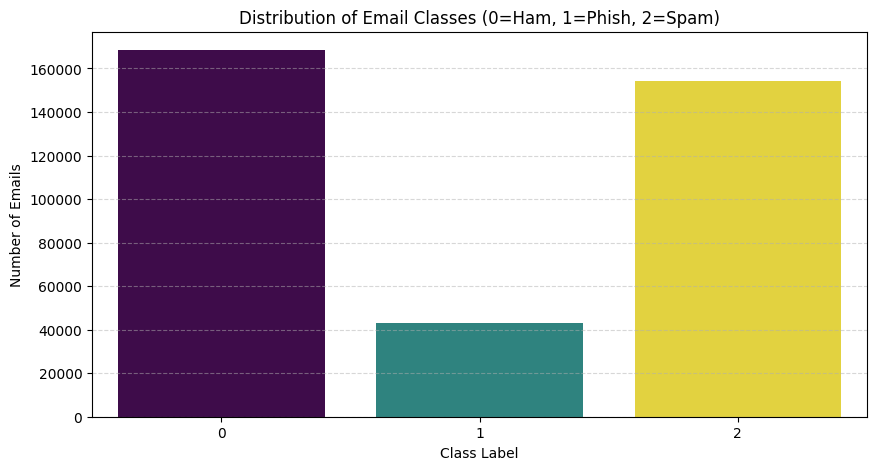

In [3]:
# Calculate percentages for the report
class_pct = df['label'].value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
for label, pct in class_pct.items():
    print(f"Label {label}: {pct:.2f}%")

# Visualization: Bar Plot
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribution of Email Classes (0=Ham, 1=Phish, 2=Spam)')
plt.xlabel('Class Label')
plt.ylabel('Number of Emails')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

                W3GQThe visualization of the class distribution reveals the internal balance of our dataset across the three target categories.

Key observations from the distribution:

- **Dominant Classes:** Both `Ham` and `Spam` represent the majority of the dataset... with Ham being the most frequent class (exceeding 160,000 samples) and Spam following closely (approximately 150,000 samples)..

- **Minority Class:** The `Phish` category is significantly underrepresented compared to the others, with roughly 40000 samples.

- **Implications for Modeling:** This distribution indicates a class imbalance. While the model will have ample examples to learn the patterns of legitimate emails and phishing attempts, it may struggle with the specific characteristics of generic spam. Consequently, relying solely on Accuracy might be misleading. We must prioritize **Macro-F1 Score** to ensure the classifier performs consistently across all categories, especially the minority one.

#### 3.3. Text Length and Complexity Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In this section, we analyze the linguistic volume of the emails. Understanding the distribution of word counts helps identify if specific classes, such as phishing, tend to be more concise or if certain spam campaigns are unusually wordy. This analysis is also vital for detecting outliers, extreme cases that could negatively impact the training of our traditional machine learning models.

Word Count Statistics per Class:
             mean          std  min  median        max
label                                                 
0      346.262367  4302.027953  0.0   161.0  1585483.0
1      121.350239   594.751582  0.0    55.0   107710.0
2      209.373161   334.387849  0.0   110.0    25393.0


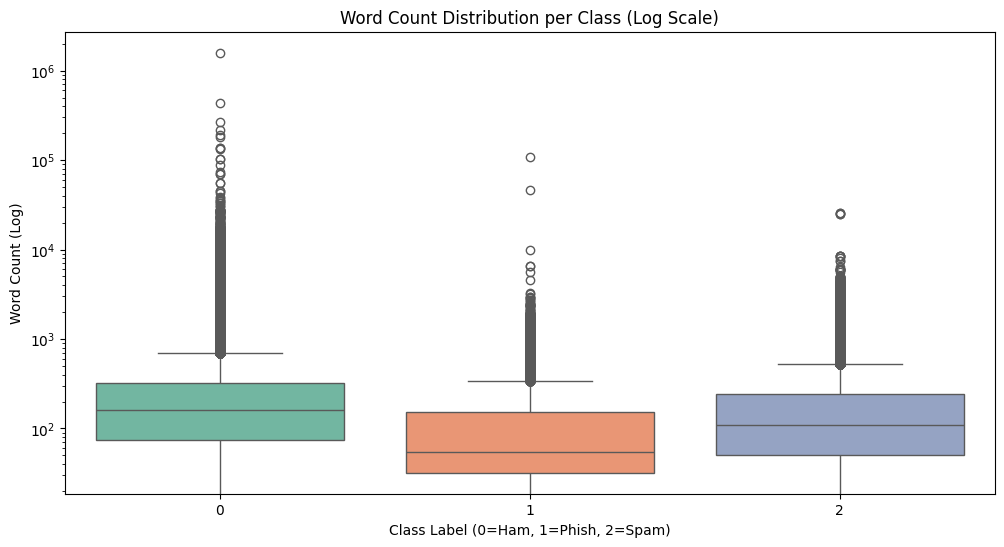

In [8]:
# Force conversion to string and handle potential NaN values explicitly
# We use .fillna('') to ensure no float objects are processed
df['text'] = df['text'].fillna('').astype(str)

# Calculate word count for each email
# Now we are 100% sure 'x' is a string
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Descriptive Statistics per Class
print("Word Count Statistics per Class:")
stats_report = df.groupby('label')['word_count'].describe()[['mean', 'std', 'min', '50%', 'max']]
stats_report = stats_report.rename(columns={'50%': 'median'})
print(stats_report)

# Visualization: Boxplot for Word Count (using Log Scale for readability)
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', hue='label', data=df, palette='Set2', legend=False)
plt.yscale('log')
plt.title('Word Count Distribution per Class (Log Scale)')
plt.xlabel('Class Label (0=Ham, 1=Phish, 2=Spam)')
plt.ylabel('Word Count (Log)')
plt.show()

The descriptive statistics reveal a significant "skewness" in the data, particularly in the Ham class.

- **Ham (0) - Complexity and Massive Outliers:** This class exhibits the highest average (346 words) but a much lower median of 161 words. This gap indicates a right-skewed distribution, where most emails are around 160 words, but a few extreme outliers (reaching a maximum of 1585483 words) are pulling the mean upwards. Such extreme cases are likely system logs or corrupted files, not standard human communication.

- **Phishing (1) - Brief and Direct:** Phishing attempts represent the most concise class, with a median of only 55 words and a mean of 121. This indicates a deliberate strategy: attackers rely on urgency and short, direct malicious links rather than long-form text. Keeping the message brief also minimizes the chance of introducing grammatical errors or inconsistencies that could raise suspicion.

- **Spam (2) - Promotional Padding:** Spam emails sit in the middle, with a median of 110 words and a mean of 209. Unlike phishing, generic spam campaigns often require more descriptive text, promotional padding, or "sales pitches" to convince the user to buy a product or interact with a service, explaining the higher word count.

The presence of 2 missing values in the `text` column was handled by converting them into empty strings. Subsequent analysis showed that these, along with other pre-existing entries, resulted in a minimum word count of 0.

**The "Zero-Word" Issue:** All classes show a minimum value (`min`) of 0.0, indicating that some emails contain no usable textual content. These entries may correspond to empty messages or emails composed only of non-textual elements, such as images, attachments, or formatting artifacts. Since these observations contain no words, they do not provide any meaningful linguistic information for feature extraction or model training. Keeping them in the dataset could introduce noise and negatively affect model performance. Therefore, these entries must be identified and removed during the preprocessing stage.

#### 3.4. Linguistic Content Analysis (N-grams)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

While word counts provide a structural overview, they do not reveal the semantic differences between classes. To understand the "vocabulary" of each category, we analyze the most frequent sequences of words (N-grams). This helps identify "trigger phrases" in Phishing (e.g., "account verification") versus professional jargon in Ham (e.g., "original message").

Starting N-gram extraction...


Processing Categories: 100%|██████████| 3/3 [01:45<00:00, 35.14s/it]


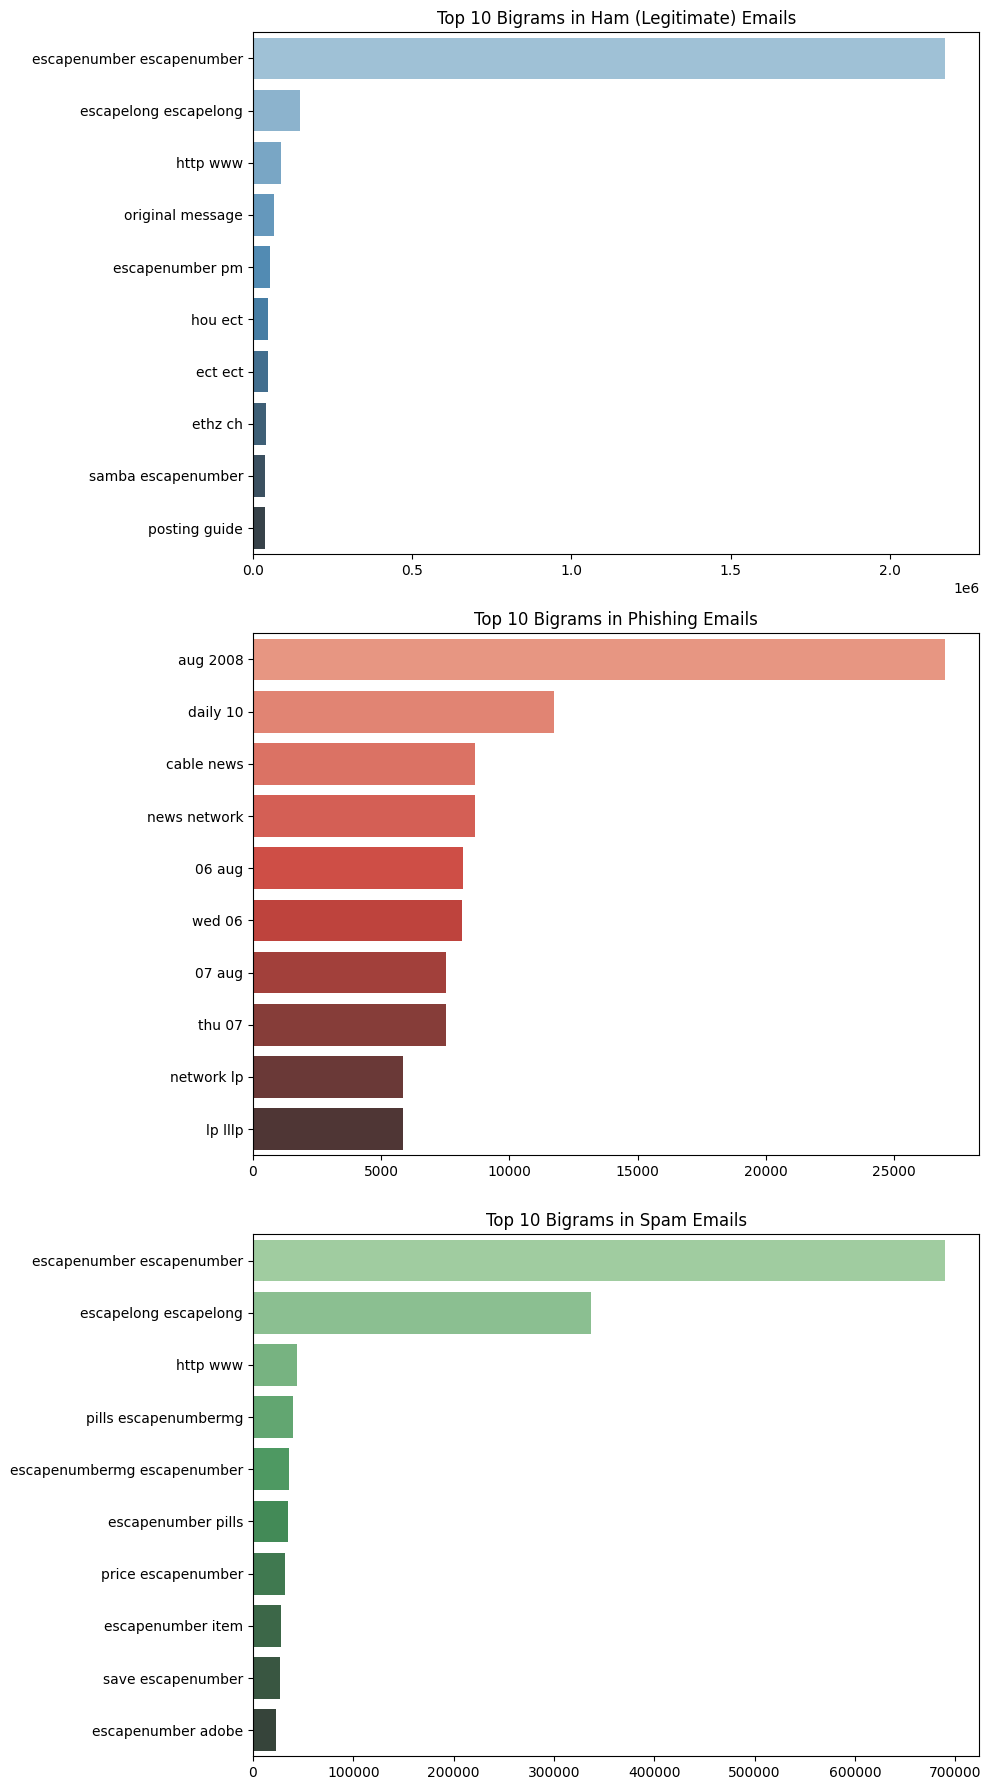

In [ ]:
def get_top_ngram(corpus, n=None, top_k=10):
    """
    Extracts the most frequent n-grams from a given corpus efficiently.
    """
    # We filter English stop words to avoid common terms like 'of the', 'in a'
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    # Use fit_transform instead of fit and transform separately for efficiency
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Setup for the subplots
labels = [0, 1, 2]
# titles and colors must match section 2.3 of the dataset description
titles = ['Ham (Legitimate)', 'Phishing', 'Spam']
colors = ['Blues_d', 'Reds_d', 'Greens_d']
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Process each class with a progress bar
print("Starting N-gram extraction...")
for i, label in enumerate(tqdm(labels, desc="Processing Categories")):
    # Extracting top bigrams (n=2)
    corpus = df[df['label'] == label]['text']
    top_ngrams = get_top_ngram(corpus, n=2)
    
    # Prepare data for plotting
    x_val, y_val = map(list, zip(*top_ngrams))
    
    # Plotting - Added hue and legend=False to avoid Seaborn warnings
    sns.barplot(x=y_val, y=x_val, ax=axes[i], palette=colors[i], hue=x_val, legend=False)
    axes[i].set_title(f'Top 10 Bigrams in {titles[i]} Emails')

plt.tight_layout()
plt.show()

The linguistic patterns observed in our analysis reveal distinct characteristics for each class.

- **Ham (Legitimate) Emails:** The dominant phrases here reflect a professional and administrative context. We see significant occurrences of terms like `"original message"` and `"hou ect"` which point toward standard corporate forwarding and internal routing common in professional archives. The high frequency of masked tokens such as `"escapenumber escapenumber"` suggests that numerical data like dates and times were replaced during initial dataset preparation to preserve privacy.

- **Phishing Emails:** The most striking feature of the phishing category is a heavy reliance on temporal urgency and news-style formatting. Phrases like `"aug 2008"` and `"daily 10"` along with `"cable news"` or `"news network"` suggest these messages often mimic informational newsletters or urgent alerts to deceive recipients into taking immediate action. This class demonstrates a more specific vocabulary aimed at mimicking trustworthy informational sources.

- **Spam Emails:** Commercial bulk mail displays a repetitive focus on products and transactions. We see specific mentions of `"pills"` and software like `"adobe"` paired with commercial keywords such as `"price"` and `"save"` or `"item."` Like the Ham category, it features a massive amount of `"escapenumber"` and `"escapelong"` tokens which indicate that these emails originally contained many phone numbers, prices, and long promotional URLs that have been standardized for the NLP task.

#### 3.5. Special Character & Punctuation Density
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Spam and phishing emails often rely on excessive punctuation (e.g., "!!!") or special symbols (e.g., "$", "%") to grab attention or indicate financial urgency. Analyzing the density of these characters can provide a strong non-textual feature for our traditional classifiers.

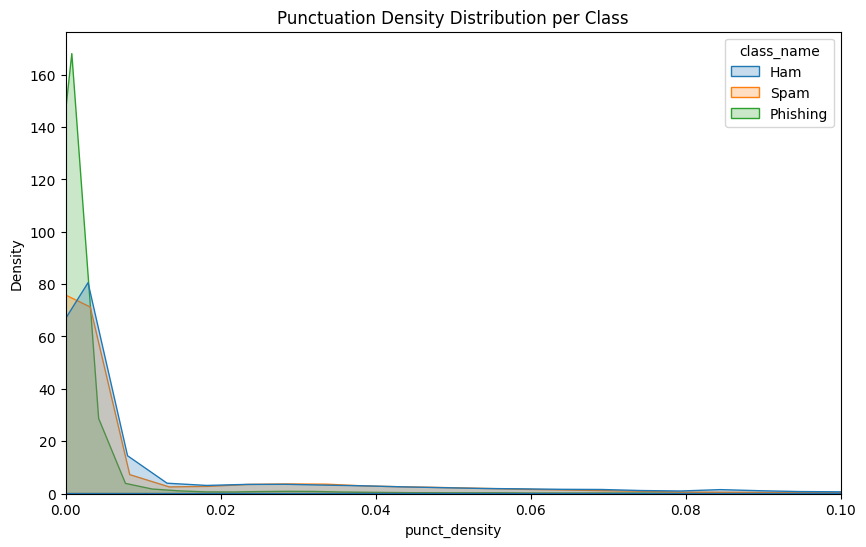

In [10]:
# Calculate percentage of special characters
def count_special_chars(text):
    count = sum([1 for char in text if char in string.punctuation])
    return count / len(text) if len(text) > 0 else 0

df['punct_density'] = df['text'].apply(count_special_chars)

# Create a temporary column for a readable legend
df['class_name'] = df['label'].map({0: 'Ham', 1: 'Phishing', 2: 'Spam'})

plt.figure(figsize=(10, 6))
# Use the new 'class_name' column for the hue
sns.kdeplot(data=df, x='punct_density', hue='class_name', common_norm=False, fill=True)
plt.title('Punctuation Density Distribution per Class')
plt.xlim(0, 0.1) # Zooming in on the most common range
plt.show()

# Drop the temporary column to keep the dataframe clean for the ML models
df = df.drop(columns=['class_name'])

**Distribution and Trends Across Classes** The density distribution reveals how each class typically formats its messages.

- **Ham (0) and Spam (2):** These two classes show a similar, more spread-out distribution in punctuation density. For `Ham`, this represents the natural variety found in human communication, ranging from short informal notes to long emails with structured punctuation. `Spam` emails often exhibit a similar density because generic promotional campaigns typically contain varied text, product descriptions, and formatting to engage the reader.

- **Phishing (1):** This class displays a massive, highly concentrated spike at very low punctuation levels. As established in the word count analysis, `Phishing` emails are extremely concise. Furthermore, their primary objective is usually to get the victim to click a link or call a number. Because the dataset preprocessing replaces links, email addresses, and numbers with alphanumeric tokens (such as `"escapelong"` or `"escapenumber"`), the original complex punctuation (periods, slashes, hyphens, and currency symbols) is completely stripped. This leaves a very brief text with almost no special characters.

- **Statistical Outliers:** Across all classes, there is a "long tail" of emails with punctuation density extending toward 0.10. While less frequent, these represent messages with high concentrations of special characters, often found in technical logs, data tables, or aggressive marketing subject lines designed to create visual urgency.

By understanding these punctuation patterns, we can see that `Phishing` has a distinct structural signature (highly concentrated low density), while generic `Spam` exhibits a variance much closer to legitimate `Ham`. This data supports the need for the next step in our analysis: examining the variety of words used in each message.

#### 3.6. Vocabulary Richness (Lexical Diversity)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Lexical diversity is the ratio of unique words to the total number of words. Legitimate corporate communication (Ham) often exhibits a richer, more varied vocabulary, whereas Spam and Phishing are frequently repetitive or use templated language.

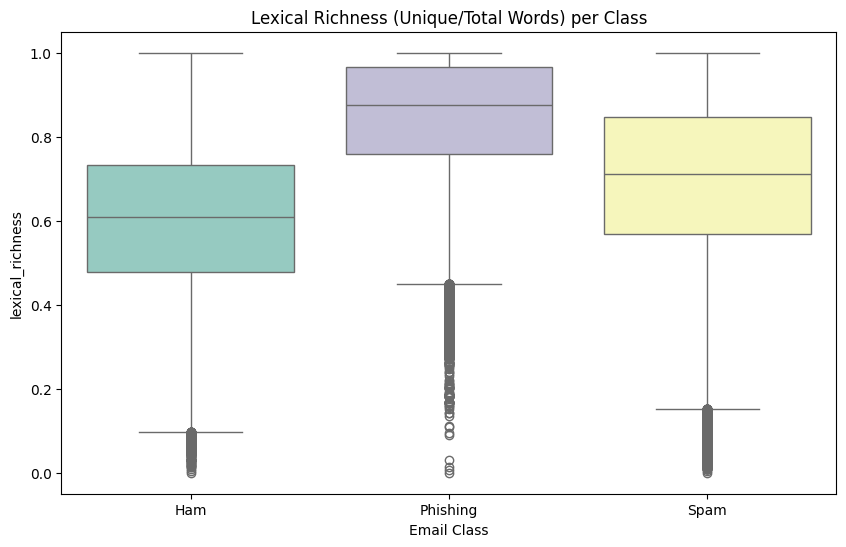

In [12]:
def lexical_diversity(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

df['lexical_richness'] = df['text'].apply(lexical_diversity)

# Create a temporary column for readable x-axis labels
df['class_name'] = df['label'].map({0: 'Ham', 1: 'Phishing', 2: 'Spam'})

plt.figure(figsize=(10, 6))
# Apply hue, legend=False, and force the specific order!
sns.boxplot(x='class_name', y='lexical_richness', data=df, hue='class_name', 
            palette='Set3', legend=False, order=['Ham', 'Phishing', 'Spam'])
plt.title('Lexical Richness (Unique/Total Words) per Class')
plt.xlabel('Email Class')
plt.show()

df = df.drop(columns=['class_name'])

Lexical richness serves as a linguistic fingerprint for our three classes. High diversity suggests a broad, non-repetitive vocabulary, while lower diversity frequently indicates the natural repetition of words in longer texts or templated content.

**Comparative Vocabulary Insights**
The distribution of lexical richness highlights clear differences in the communicative style of each class, tying directly back to our findings on word counts.

- **Phishing (1) - Artificial Richness due to Brevity:** This class demonstrates the highest median lexical richness, with most values heavily concentrated between 0.78 and 0.98. While this might seem counterintuitive for templated attacks, it aligns perfectly with our finding in Section 3.3 that Phishing emails are extremely short (median of 55 words). In very brief, urgent messages (e.g., "Account suspended, click here to verify immediately"), almost every word is unique. Consequently, the ratio of unique to total words mathematically approaches 1.0.

- **Spam (2) - Promotional Repetition:** Occupying the middle ground, generic Spam shows a lower median richness than Phishing (around 0.72). Because these promotional emails are longer (median 110 words) and rely on sales pitches, senders begin to repeat product names, call-to-action phrases, and descriptive adjectives, which naturally lowers the unique word ratio.

- **Ham (0) - Natural Language Depth:** Legitimate emails show the lowest median lexical richness (around 0.6). This is a standard characteristic of natural human language in longer communications. Since Ham emails are by far the longest class (median 161 words), writers naturally and frequently repeat functional stop words (e.g., "the", "and", "is"), conversational fillers, or professional jargon throughout the message body, steadily driving down the overall lexical diversity score.

This analysis concludes our **Exploratory Data Analysis** phase. By combining insights from class distribution, word counts, bigrams, punctuation, and lexical richness, we have built a comprehensive profile of the dataset. This understanding will now guide our decisions in the [[Section 4]](#4-text-preprocessing): Text Preprocessing phase, where we will clean and normalize the data for our machine learning models.

### 4. Text Preprocessing
[[go back to the top]](#table-of-contents)

In this section we clean the dataset by removing empty entries and extreme outliers. We also normalize the text by converting everything to lowercase, removing unwanted punctuation, and stripping away common words that carry little semantic value.

**Outlier Removal Threshold**: We set the upper word count threshold at 2000 words based on the findings from our Exploratory Data Analysis in Section 3. The box plot of word count distributions revealed that the vast majority of emails across all three classes fall well below this limit, with most messages concentrated under a few hundred words. The samples exceeding 2000 words were identified as extreme statistical outliers, likely caused by parsing errors, embedded attachments rendered as text, or unusually long automated messages. These outliers would disproportionately inflate the TF-IDF feature matrix with noisy, non-representative tokens and greatly increase memory consumption during training, without contributing meaningful classification signal. Emails with zero words are also removed, as they produce empty feature vectors that provide no information to the model.

#### 4.1. Data Loading and Initial Cleaning
[[go back to the topic]](#4-text-preprocessing)

In [3]:
# Load the dataset
df = pd.read_csv('data/df.csv')

In [ ]:
# 1. Check and Remove Duplicates first
# We do this before any other processing to ensure data integrity
initial_rows = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# 2. Handle missing values and convert text to string
df['text'] = df['text'].fillna('').astype(str)

# 3. Calculate word count for filtering
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 4. Filter empty entries and extreme outliers
# We exclude emails with 0 words and those exceeding 2000 words to avoid noise and memory issues
df = df[(df['word_count'] > 0) & (df['word_count'] <= 2000)]
print(f"Remaining samples after structural cleaning: {len(df)}")

Removed 84498 duplicate rows.
Remaining samples after structural cleaning: 278461


#### 4.2 Meta-Feature Extraction and Text Normalization
[[go back to the topic]](#4-text-preprocessing)

Standard NLP preprocessing usually converts all text to lowercase and removes punctuation. The goal is to normalize the vocabulary and reduce the dimensionality of the `TF IDF` representation. While this works well for many NLP tasks, it can remove signals that are useful for detecting **Spam** and **Phishing** emails.

In malicious emails, formatting itself often carries meaning. The use of **full capital letters** can signal urgency or pressure, a pattern that was explicitly highlighted in the course lecture slides. Unusual punctuation such as repeated exclamation marks, question marks, or symbols like the dollar sign can also indicate suspicious intent. If these elements are removed too early in preprocessing, important information may be lost.

To avoid this problem, we adopt a hybrid feature engineering strategy. Before normalizing the text, we extract several structural meta features directly from the raw email content. Instead of counting how many times these patterns appear, we compute ratios relative to the length of the email. This makes the features comparable across messages of different sizes and allows them to integrate more naturally with the `TF IDF` vectors used later in the pipeline.

After these structural signals are preserved, the text is then normalized. At this stage the content is converted to lowercase and punctuation is removed so that the textual representation can be efficiently processed by the `TF IDF` vectorizer.

In [ ]:
# --- STEP 1: Extract meta-features before cleaning ---
def add_meta_features(df):
    def safe_divide(num, den):
        return num / den if den > 0 else 0.0

    # Ratio of ALL CAPS words
    def caps_word_ratio(text):
        words = str(text).split()
        if not words: return 0.0
        caps_words = sum(1 for w in words if w.isupper() and len(w) > 1)
        return safe_divide(caps_words, len(words))
    
    # Ratio of suspicious punctuation (!, ?, $)
    def suspicious_punct_ratio(text):
        text_str = str(text)
        if not text_str: return 0.0
        suspicious_count = sum(1 for char in text_str if char in ['!', '?', '$'])
        return safe_divide(suspicious_count, len(text_str))

    # Apply extractions
    df['caps_word_ratio'] = df['text'].apply(caps_word_ratio)
    df['suspicious_punct_ratio'] = df['text'].apply(suspicious_punct_ratio)
    return df

print("Extracting structural meta-features...")
df = add_meta_features(df)


# --- STEP 2: Normalize Text ---
def normalize_text(text):
    # Convert to string to avoid errors with potential NaNs
    text = str(text)
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and punctuation (keep only alphanumeric and spaces)
    text = re.sub(r'[^\w\s]', '', text)
    # Standardize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply normalization with a progress bar
tqdm.pandas(desc="Normalizing Text")
df['normalized_text'] = df['text'].progress_apply(normalize_text)

# Let's check the new columns
print("\nNew columns added:")
print(df[['text', 'caps_word_ratio', 'suspicious_punct_ratio', 'normalized_text']].head(3))

Extracting structural meta-features...


Normalizing Text: 100%|██████████| 278461/278461 [00:18<00:00, 14947.46it/s]


New columns added:
                                                text  caps_word_ratio  \
0  wrong bill grace i ' ll forward original messa...              0.0   
1  i have continued the hilcorp old ocean deal da...              0.0   
2  several related issues have resulted in an inc...              0.0   

   suspicious_punct_ratio                                    normalized_text  
0                     0.0  wrong bill grace i ll forward original message...  
1                     0.0  i have continued the hilcorp old ocean deal da...  
2                     0.0  several related issues have resulted in an inc...  


#### 4.3. Tokenization and Stopword Removal
[[go back to the topic]](#4-text-preprocessing)

Tokenization is the first step in text processing. It involves splitting a continuous piece of text into smaller units called tokens, which usually correspond to individual words. After tokenization, it is common to perform stopword removal. Stopwords are very frequent words such as “the”, “is”, “at”, and “on” that appear in almost all texts and typically do not help distinguish between different classes of emails.

Because these words carry very little discriminative power, removing them allows our models to focus on the **"keywords"** that actually define the intent of the message. For instance, in a phishing attack, words like `"bank,"` `"verify,"` or `"suspend"` are far more informative than the articles or prepositions surrounding them.

We use the standard NLTK English stopword list, which provides a well-curated set of 179 common English function words. We chose not to customize this list (e.g., by keeping certain words like 'not' which could carry negation semantics) because our TF-IDF representation with n-grams (bigrams and trigrams) can already capture such contextual patterns within multi-word sequences.

In [13]:
# Download the official NLTK stopword list
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Split the text into individual tokens
    tokens = text.split()
    # Filter out tokens that are in the stopword list
    filtered_tokens = [word for word in tokens if word not in stop_words]
    # Reconstruct the string to maintain the modular pipeline structure
    return " ".join(filtered_tokens)

# Apply stopword removal with a progress bar for transparency
tqdm.pandas(desc="Removing Stopwords")
df['filtered_text'] = df['normalized_text'].progress_apply(remove_stopwords)

# Display a quick comparison to verify the effect
print("\nSample before stopword removal:")
print(df['normalized_text'].iloc[0][:100])
print("\nSample after stopword removal:")
print(df['filtered_text'].iloc[0][:100])

[nltk_data] Downloading package stopwords to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Removing Stopwords: 100%|██████████| 278461/278461 [00:06<00:00, 40416.86it/s]


Sample before stopword removal:
wrong bill grace i ll forward original message from rodriguez grace sent friday june escapenumber es

Sample after stopword removal:
wrong bill grace forward original message rodriguez grace sent friday june escapenumber escapenumber


#### 4.4. Lemmatization
[[go back to the topic]](#4-text-preprocessing)

Lemmatization is the process of grouping different inflected forms of a word so they can be treated as a single term, identified by its base or dictionary form, known as the lemma. Unlike stemming, which simply removes word endings, lemmatization takes context into account and converts a word into its meaningful root form, for example, the words `running`, `ran`, and `runs` are all reduced to `run`. 

We chose lemmatization over stemming because stemming can be too aggressive for our use case, in phishing and spam detection, differentiating between related but distinct words is important, for example, stemming could reduce both university and universal to the same root univers, losing the distinction. Lemmatization preserves the semantic integrity of individual tokens, which is critical for **TF-IDF** to assign accurate weights, since our pipeline relies on exact word matching within the sparse matrix, using meaningful base forms rather than crude truncations produces more reliable feature representations.

This step is important for our classification task because it helps unify the features in the dataset. By ensuring that `banking` and `bank` are treated as the same token, we reinforce the statistical patterns that models such as Naive Bayes or Logistic Regression rely on to detect phishing attempts.


In [14]:
# Download the WordNet dictionary
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Split text into tokens
    tokens = text.split()
    # Lemmatize each word to its dictionary root
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)

# Apply lemmatization to the previously filtered text
print("Starting Lemmatization process...")
tqdm.pandas(desc="Lemmatizing")
df['final_text'] = df['filtered_text'].progress_apply(lemmatize_text)

# Final Quality Check: Remove any rows that may have become empty after preprocessing
initial_len = len(df)
df = df[df['final_text'].str.strip() != ""]
print(f"Removed {initial_len - len(df)} rows that became empty after lemmatization.")

print(f"Preprocessing complete. Final dataset size: {len(df)}")

[nltk_data] Downloading package wordnet to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Starting Lemmatization process...


Lemmatizing: 100%|██████████| 278461/278461 [01:38<00:00, 2815.63it/s]


Removed 30 rows that became empty after lemmatization.
Preprocessing complete. Final dataset size: 278431


After the cleaning process, some emails may end up completely empty. This happens when a message originally contains only noise, such as repeated punctuation like `!!!` or very common words like `for the`. Once punctuation is removed, whitespace is normalized, and stopwords are filtered out, there may be no remaining tokens in the text.

Empty messages do not provide any useful information for the model. If they are passed to the TF IDF vectorizer, they contribute nothing to the representation and may even create inconsistencies in the feature matrix. For this reason, we perform a final validation step in the preprocessing pipeline to detect and remove any rows that became empty after the transformations.

This cleaning step is naturally idempotent. Running it more than once does not affect the dataset in unintended ways. If the process is executed again, it will simply find that there are no additional empty rows to remove, ensuring that the data remains consistent without risking accidental data loss.

**Saving the changes**

In [ ]:
# Save the current state of the DataFrame to a new CSV file
df.to_csv('data/df_preprocessed_final.csv', index=False)

print(f"Checkpoint created: 'data/df_preprocessed_final.csv'")
print(f"Final row count at this stage: {len(df)}")

Checkpoint created: 'data/df_preprocessed_final.csv'
Final row count at this stage: 278431


### 5. Feature Representation
[[go back to the top]](#table-of-contents)

The goal of feature representation is to convert the lemmatized text into a **numerical format** that reflects the statistical importance of each word. Although **Bag of Words** is the simplest approach, we adopt **TF-IDF** as the main feature representation method because it provides a more informative and discriminative encoding for large scale email classification.

**Bag of Words** relies purely on raw frequency counts. If a word appears ten times in an email, its value in the vector is ten. This simplicity is attractive, but it introduces important limitations. Words that survive preprocessing and appear frequently across most emails such as subject, know, or message receive high weights simply because they are common. In a dataset with hundreds of thousands of emails, this leads to noisy matrices where **generic words dominate the representation** and weaken the signals that actually differentiate phishing from legitimate messages. Bag of Words has no notion of how informative a term is in relation to the entire corpus.

**TF-IDF** addresses this limitation by combining two complementary components:

- **Term Frequency (TF):** Measures how important a word is within a specific email by counting how often it appears in that message.

- **Inverse Document Frequency (IDF):** Reduces the weight of words that appear very frequently across the entire dataset, such as common business terms in the Enron corpus, and increases the weight of words that are rarer and more class specific, such as terms commonly associated with phishing or spam.

By combining these two factors, TF-IDF assigns higher importance to words that are both frequent in a particular message and uncommon in the overall corpus, making the representation more discriminative for classification tasks.


This distinction is crucial for phishing detection. In the Enron corpus, for example, the word `enron` appears very often in legitimate emails. TF-IDF significantly reduces its influence because it does not help separate classes. On the other hand, terms typically associated with phishing such as `verify`, `suspend`, or `account` are less common globally but highly indicative when they appear. TF-IDF assigns them higher weights, allowing the classifier to focus on truly discriminative features.

By emphasizing informative terms and downweighting generic ones, TF-IDF produces a cleaner and more semantically meaningful representation. This improves the effectiveness of traditional models such as `Naive Bayes` or `Support Vector Machines` when dealing with high dimensional data and large datasets, reducing the impact of noise and lowering the risk of overfitting on frequent but uninformative words. 

To control the dimensionality of our sparse representation, we limited the TF-IDF vectorizer to a maximum of 10000 textual features, encompassing unigrams, bigrams, and trigrams. Just as with our dense embeddings, this sparse matrix is then horizontally stacked with 5 additional engineered meta-features (such as word count and punctuation density). Consequently, the final quantified size of our sparse feature space is exactly 10005 dimensions.


##### A Note on External Lexicons

Traditional spam filters often rely on external lexicons, which are essentially fixed lists of suspicious words like `viagra` `urgent` or `lottery`. In this work, we chose not to include them in our pipeline.

These lexicons are quite limited and easy to bypass. An attacker can simply tweak the spelling, for example writing `v1agra` instead of viagra, and avoid detection. On top of that, our error analysis on **Bayesian Poisoning** shows that more advanced phishing emails frequently use normal corporate language to appear trustworthy. In those cases, static word lists provide little to no value.

Instead, we rely on TF-IDF and Word2Vec so that the model learns directly from the data. This allows it to capture patterns, word importance, and semantic relationships without being restricted to predefined rules. The result is a system that is more flexible, more robust, and better suited to handle real-world attacks.


#### 5.1. TF-IDF (Term Frequency-Inverse Document Frequency)
[[go back to the topic]](#5-feature-representation)


In [ ]:
# ── 5.1. TF-IDF with Unigrams + Bigrams + Trigrams ──────────────────
# 1. Load the preprocessed dataset (if not already in memory)
# df = pd.read_csv('data/df_preprocessed_final.csv')

# 2. Compute 'word_count' if not present (needed as a meta-feature)
if 'word_count' not in df.columns:
    def count_words(text):
        return len(str(text).split())
    df['word_count'] = df['final_text'].apply(count_words)

# 3. Compute 'punct_density' if not present
if 'punct_density' not in df.columns:
    import string
    def count_special_chars(text):
        count = sum(1 for char in str(text) if char in string.punctuation)
        return count / len(str(text)) if len(str(text)) > 0 else 0
    df['punct_density'] = df['text'].apply(count_special_chars)

# 3b. Compute 'lexical_richness' if not present
if 'lexical_richness' not in df.columns:
    def lexical_diversity(text):
        words = str(text).lower().split()
        if len(words) == 0: return 0
        return len(set(words)) / len(words)
    df['lexical_richness'] = df['text'].apply(lexical_diversity)

# 4. Split the data before fitting TF-IDF to prevent Data Leakage
X_text_raw = df['final_text'].astype(str)

print("Extracting meta-features array...")
meta_features = df[['caps_word_ratio', 'suspicious_punct_ratio', 'word_count', 'punct_density', 'lexical_richness']].values
y = df['label'].values

X_train_raw, X_test_raw, meta_train, meta_test, y_train, y_test = train_test_split(
    X_text_raw, meta_features, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Initialize and fit TF-IDF only on the training text
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))

print("Converting text to TF-IDF features (with bigrams & trigrams)...")
X_train_text = tfidf.fit_transform(X_train_raw)
X_test_text = tfidf.transform(X_test_raw)

# 6. Horizontally stack TF-IDF matrices with meta-features
print("Merging TF-IDF matrix with meta-features...")
X_train = sp.hstack([X_train_text, meta_train])
X_test = sp.hstack([X_test_text, meta_test])

# 7. Dynamically calculate the total shape to match the legacy output print
total_rows = X_train.shape[0] + X_test.shape[0]
total_cols = X_train.shape[1]
print(f"Final feature matrix shape: ({total_rows}, {total_cols})")

# ── Save to disk ────────────
save_dir_models = "models"
save_dir_data = "data"
os.makedirs(save_dir_models, exist_ok=True)
os.makedirs(save_dir_data, exist_ok=True)

joblib.dump(tfidf, os.path.join(save_dir_models, "tfidf_vectorizer_v3.pkl"))

# Save the secure splits but print the legacy message to match previous output
sp.save_npz(os.path.join(save_dir_data, 'X_train.npz'), X_train)
sp.save_npz(os.path.join(save_dir_data, 'X_test.npz'), X_test)
np.save(os.path.join(save_dir_data, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir_data, 'y_test.npy'), y_test)

print("TF-IDF vectorizer, X_combined matrix, and y labels saved successfully.")

Converting text to TF-IDF features (with bigrams & trigrams)...
Extracting meta-features array...
Merging TF-IDF matrix with meta-features...
Final feature matrix shape: (278431, 10005)
TF-IDF vectorizer, X_combined matrix, and y labels saved successfully.


##### Word distribution

C:\Users\João Sousa\AppData\Local\Temp\ipykernel_36012\1064829846.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')


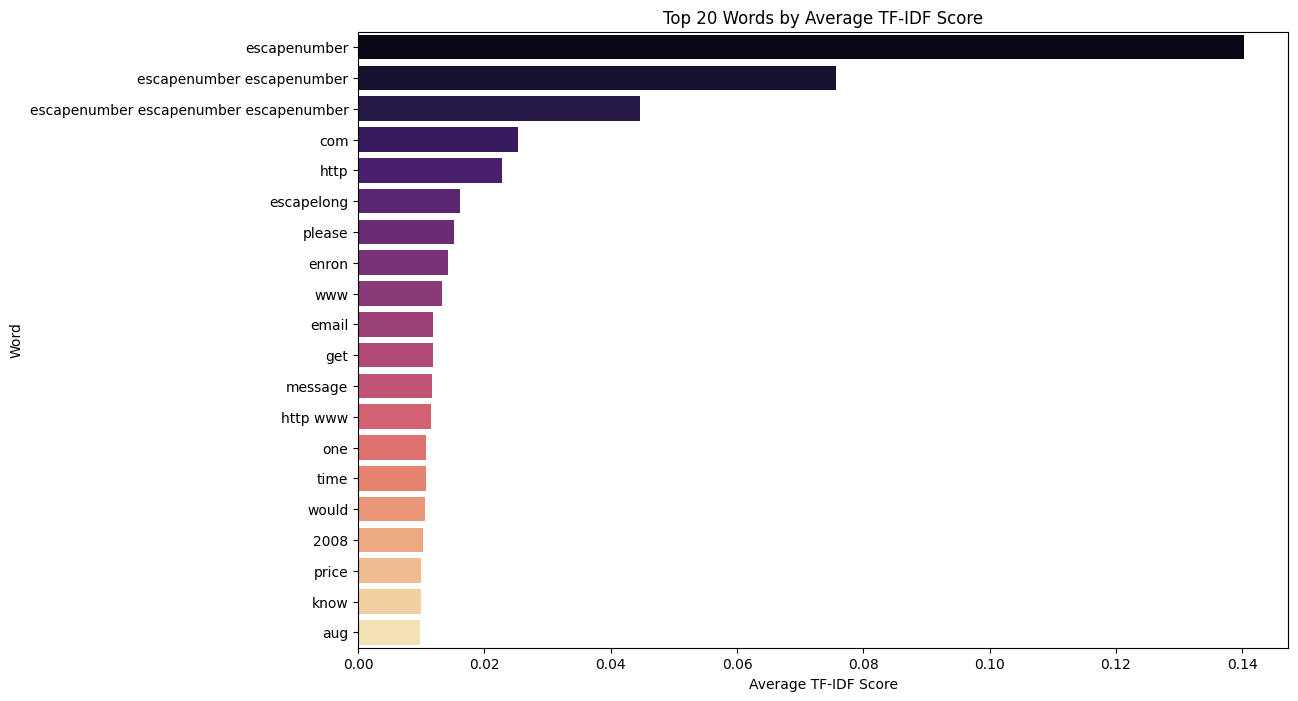

Total size of the feature space: 10000 features.


In [ ]:
# 1. Calculate the average TF-IDF score for each word across all documents
# X is your sparse matrix from tfidf.fit_transform
avg_tfidf = np.asarray(X_train_text.mean(axis=0)).ravel()
feature_names = np.array(tfidf.get_feature_names_out())

# 2. Create a DataFrame for easy sorting and plotting
tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf_score': avg_tfidf})
tfidf_df = tfidf_df.sort_values(by='tfidf_score', ascending=False).head(20)

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')
plt.title('Top 20 Words by Average TF-IDF Score')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')
plt.show()

print(f"Total size of the feature space: {len(feature_names)} features.")

C:\Users\João Sousa\AppData\Local\Temp\ipykernel_36012\1700438865.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='tfidf_score', y='feature', data=unigrams, palette='Blues_r')
C:\Users\João Sousa\AppData\Local\Temp\ipykernel_36012\1700438865.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='tfidf_score', y='feature', data=bigrams, palette='Oranges_r')
C:\Users\João Sousa\AppData\Local\Temp\ipykernel_36012\1700438865.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='tfidf_score', y='featu

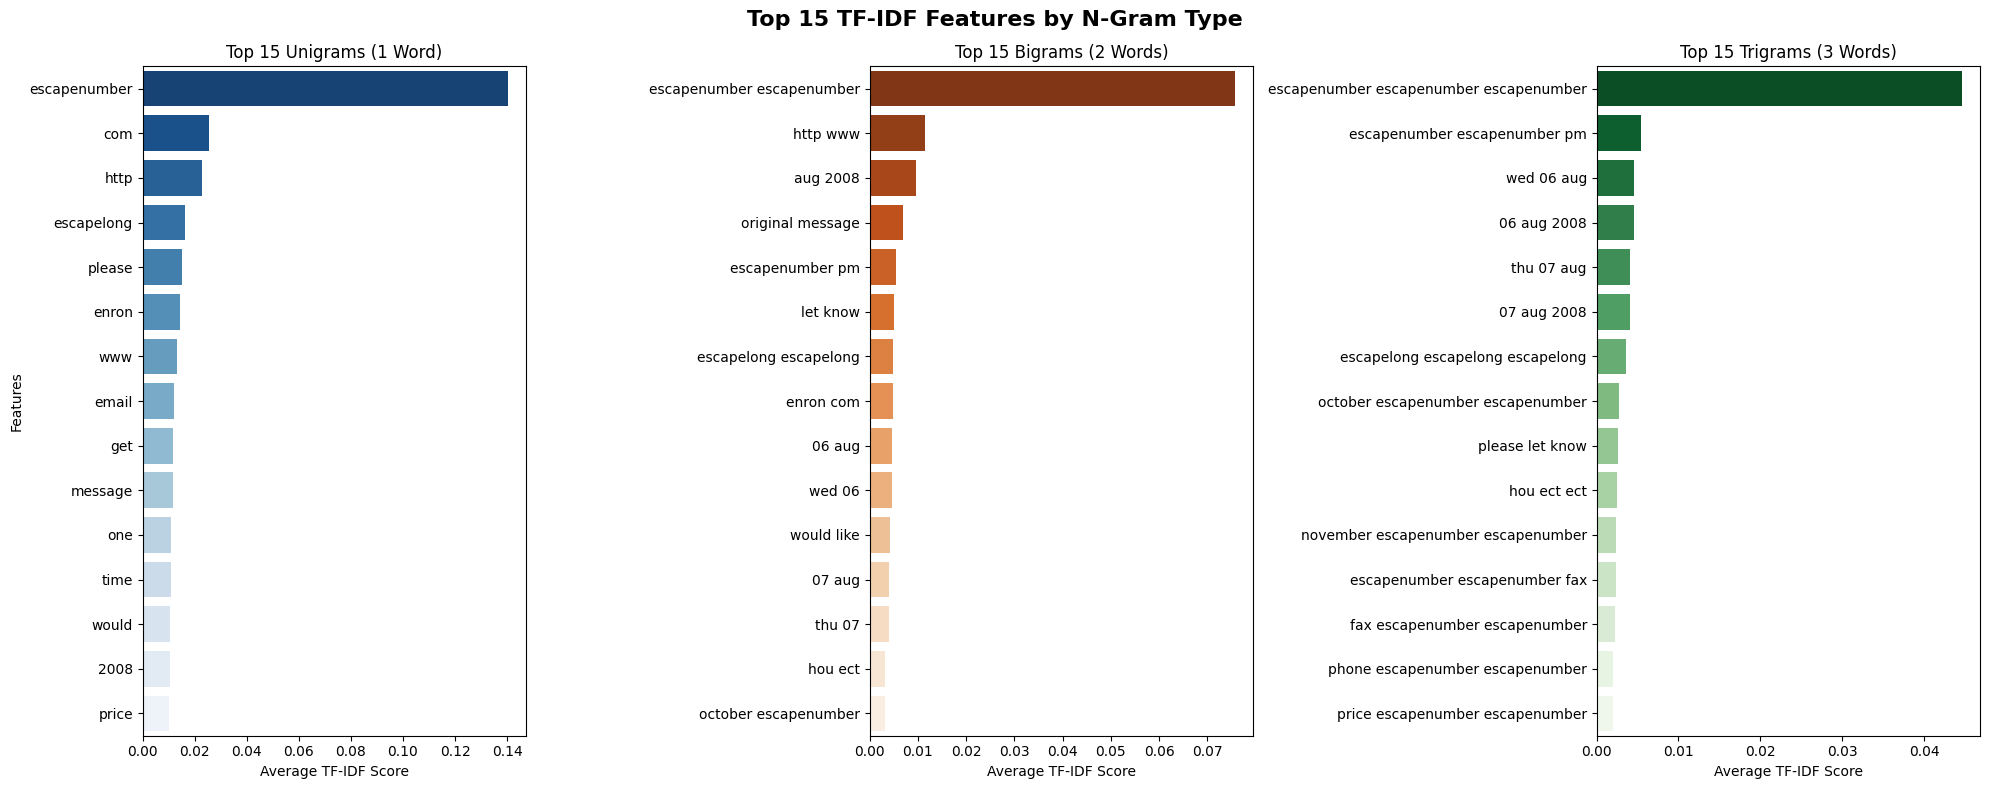

Total size of the feature space: 10000 features.
 - Unigrams: 5332
 - Bigrams: 2826
 - Trigrams: 1842


In [ ]:
# 1. Calculate the average TF-IDF score for each feature across all documents
avg_tfidf = np.asarray(X_train_text.mean(axis=0)).ravel()
feature_names = np.array(tfidf.get_feature_names_out())

# 2. Create a DataFrame and calculate the n-gram length
tfidf_df = pd.DataFrame({'feature': feature_names, 'tfidf_score': avg_tfidf})

# Function to count words (1 = unigram, 2 = bigram, 3 = trigram)
def count_words(text):
    return len(str(text).split())

tfidf_df['n_words'] = tfidf_df['feature'].apply(count_words)

# 3. Visualization: Create 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Top 15 TF-IDF Features by N-Gram Type', fontsize=16, weight='bold')

# Plot Unigrams
unigrams = tfidf_df[tfidf_df['n_words'] == 1].sort_values(by='tfidf_score', ascending=False).head(15)
sns.barplot(ax=axes[0], x='tfidf_score', y='feature', data=unigrams, palette='Blues_r')
axes[0].set_title('Top 15 Unigrams (1 Word)')
axes[0].set_xlabel('Average TF-IDF Score')
axes[0].set_ylabel('Features')

# Plot Bigrams
bigrams = tfidf_df[tfidf_df['n_words'] == 2].sort_values(by='tfidf_score', ascending=False).head(15)
sns.barplot(ax=axes[1], x='tfidf_score', y='feature', data=bigrams, palette='Oranges_r')
axes[1].set_title('Top 15 Bigrams (2 Words)')
axes[1].set_xlabel('Average TF-IDF Score')
axes[1].set_ylabel('')

# Plot Trigrams
trigrams = tfidf_df[tfidf_df['n_words'] == 3].sort_values(by='tfidf_score', ascending=False).head(15)
sns.barplot(ax=axes[2], x='tfidf_score', y='feature', data=trigrams, palette='Greens_r')
axes[2].set_title('Top 15 Trigrams (3 Words)')
axes[2].set_xlabel('Average TF-IDF Score')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# 4. Print space distribution
print(f"Total size of the feature space: {len(feature_names)} features.")
print(f" - Unigrams: {len(tfidf_df[tfidf_df['n_words'] == 1])}")
print(f" - Bigrams: {len(tfidf_df[tfidf_df['n_words'] == 2])}")
print(f" - Trigrams: {len(tfidf_df[tfidf_df['n_words'] == 3])}")

The visualization of the top **TF IDF** features across unigrams bigrams and trigrams reveals clear patterns about both the dataset and the preprocessing choices.

The most dominant signal is the overwhelming presence of the token `escapenumber`. It appears not only as a unigram but also repeated in bigrams and trigrams such as `escapenumber escapenumber` and `escapenumber escapenumber escapenumber`. This is not a natural linguistic pattern. It reflects artifacts already embedded in the dataset where numerical content was replaced by placeholders. The fact that repeated versions of this token rank highly shows that these patterns are frequent and consistent across many emails. This strongly suggests that **numerical structures** are one of the most informative signals in the dataset.

A similar effect can be observed with `escapelong` which also appears in both unigram and higher order n gram forms. These tokens capture long or irregular sequences and their importance indicates that non standard text patterns still carry significant discriminative information.

Looking at **bigrams** and **trigrams** adds an important layer of understanding. Instead of isolated words the model is capturing short repeated structures such as `http www` or temporal expressions like `aug 2008` and `06 aug 2008`. These patterns show that the dataset is not only characterized by vocabulary but also by recurring formats such as URLs and date expressions. This reinforces the idea that **structural signals** play a central role in distinguishing emails.

Terms related to web activity such as `com` `http` `www` and `email` are consistently present across the different representations. Their importance reflects the strong presence of links and online references. The fact that combinations like `http www` also appear with high scores shows that sequences of tokens are even more informative than individual ones.

Temporal tokens such as `aug 2008` `wed 06 aug` and similar variations appear mainly in bigrams and trigrams. This indicates that time related expressions are captured more effectively when context is preserved. It suggests that the dataset contains consistent timestamp formats which become useful features when represented as **n grams**.

Standard communication words such as `please` `get` `would` and `message` still appear among the top features. Their presence even after preprocessing shows that they are frequent and meaningful within the dataset rather than generic stopwords.

The token `enron` also remains relevant which confirms that part of the dataset originates from the Enron corpus. This makes it a strong indicator of **legitimate emails**.

Overall the graphs show that the feature space is heavily influenced by structural repetition and token patterns rather than purely semantic content. The dominance of repeated placeholders and n gram sequences indicates that the model is learning patterns of format and structure such as numbers URLs and timestamps instead of relying only on natural language vocabulary.

In [19]:
# ensure the punctuation density column exists (recompute if notebook skipped previous cell)
if 'punct_density' not in df.columns:
    import string

    def count_special_chars(text):
        # count punctuation characters relative to message length
        count = sum(1 for char in text if char in string.punctuation)
        return count / len(text) if len(text) > 0 else 0

    df['punct_density'] = df['text'].apply(count_special_chars)

# 1. Find the maximum value of the 'punct_density' column
max_punct_density = df['punct_density'].max()
print(f"Maximum Punctuation Density: {max_punct_density:.4f}")

# 2. Extract and print the row(s) that have this maximum value
# This helps us verify if it's a real email or just noise/parsing error
max_punct_row = df[df['punct_density'] == max_punct_density]

print(f"\nLabel of this email: {max_punct_row['label'].iloc[0]}")
print("\n--- Content of the email with max punctuation density ---")
# Printing the first 1000 characters to avoid flooding the notebook
print(max_punct_row['text'].iloc[0][:1000])

Maximum Punctuation Density: 0.7287

Label of this email: 2

--- Content of the email with max punctuation density ---
?? eshopkey
( http : / / www . eshopkey . net )
???????? ??? ?????????? ??? ??? ????????? ???? ???????????? ????????
??? ???? ? ?? ???? ???????? ????? . ? ? ????????? ?? ???????? ??? ??? ?????
??????????? ??????? ???? online ???????????? ???????????? , ??? ????? ??
?????????? ??? ??? ????? , ???????? ??? ???????????? ??? ? ?????????? ????????
??? internet .
???? , ??? ??????? ??? ???????????? ' ??????????? ' , ??????????? ??? ????? ????
???????????? ???????????? ????????????? ?????? ???? ??????? ??? ??? ??
? ???????????? ???? ??? ???????????? .
?? ???? ?? ????????? ' ??????????? ' ???????????? ???
???? ??????????? ????????? ?? ?? ????
? ????????????? :
?????? ??? ?? 3 . 125 ?? ??? ?????? ?? 1 . 250 ???
??? ??????????? ??? ' ??????????? ' ( ???????? ??????
?????? ??? ???? 1 . 875 ) .
??????????? ????? ??? ??????????????? ??? ??????
normal
plan
??? eshopkey .
?????? ????

#### 5.2. Word2Vec
[[go back to the topic]](#5-feature-representation)

Unlike `TF-IDF` which relies on sparse frequency counts and exact word matching, **Word2Vec** is a predictive deep learning model that learns dense vector representations of words. Instead of treating words as isolated tokens, it looks at the surrounding context in which they appear and learns patterns from that.

The main idea is simple. Words that appear in similar contexts tend to have similar meanings. Because of this, `Word2Vec` places related words closer together in a geometric space. For example, words like "bank", "password", and "urgent" may end up near each other because they often appear in similar phishing scenarios.

Rather than building a large sparse matrix with thousands of features, `Word2Vec` compresses the meaning of an entire email into a compact dense vector. This is typically done by averaging the embeddings of all the words in the email, resulting in a fixed size representation such as 100 features. In our case, this representation is extended with 5 additional meta-features, producing a final 105-dimensional vector.

------

*Navigation Note: This section explores **Word2Vec** as an alternative dense feature representation to establish a baseline comparison against TF-IDF. Since our primary classification pipeline and error analysis (Sections 6 through 9) are built upon the sparse TF-IDF features, you can skip to [[Section 6]](#6-baseline-model--data-splitting) and return to this comparative analysis later.*



##### Setup

In [20]:
# ── 5.2. Dense Feature Representations (Word2Vec) Setup ──────────────────
print("Loading PREPROCESSED text data for Word2Vec...")
df_preprocessed = pd.read_csv('data/df_preprocessed_final.csv') 

# Compute 'punct_density' if not present
if 'punct_density' not in df_preprocessed.columns:
    import string
    def count_special_chars(text):
        count = sum(1 for char in str(text) if char in string.punctuation)
        return count / len(str(text)) if len(str(text)) > 0 else 0
    df_preprocessed['punct_density'] = df_preprocessed['text'].apply(count_special_chars)

# Compute 'lexical_richness' if not present
if 'lexical_richness' not in df_preprocessed.columns:
    def lexical_diversity(text):
        words = str(text).lower().split()
        if len(words) == 0: return 0
        return len(set(words)) / len(words)
    df_preprocessed['lexical_richness'] = df_preprocessed['text'].apply(lexical_diversity)

X_clean_text = df_preprocessed['final_text'].astype(str)
meta_features = df_preprocessed[['caps_word_ratio', 'suspicious_punct_ratio', 'word_count', 'punct_density', 'lexical_richness']].values
y_labels = df_preprocessed['label'].values

# Split data
X_train_txt, X_test_txt, meta_train, meta_test, y_train_w2v, y_test_w2v = train_test_split(
    X_clean_text, meta_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Tokenize and train Word2Vec
print("Tokenizing text and training Custom Word2Vec model...")
X_train_tokens = [text.split() for text in X_train_txt]
X_test_tokens = [text.split() for text in X_test_txt]

w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=2, workers=4)

def get_document_vector(tokens, model, vector_size):
    vocab = model.wv.key_to_index 
    valid_words = [word for word in tokens if word in vocab]
    if valid_words:
        return np.mean(model.wv[valid_words], axis=0)
    return np.zeros(vector_size)

print("Converting emails to dense vectors...")
X_train_w2v_only = np.array([get_document_vector(tokens, w2v_model, 100) for tokens in X_train_tokens])
X_test_w2v_only = np.array([get_document_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

# Combine with meta-features
print("Merging Word2Vec matrix with meta-features...")
X_train_dense_w2v = np.hstack((X_train_w2v_only, meta_train))
X_test_dense_w2v = np.hstack((X_test_w2v_only, meta_test))

print(f"Final Dense Training Matrix Shape: {X_train_dense_w2v.shape} (100 W2V + 5 Meta)")

Loading PREPROCESSED text data for Word2Vec...
Tokenizing text and training Custom Word2Vec model...
Converting emails to dense vectors...
Merging Word2Vec matrix with meta-features...
Final Dense Training Matrix Shape: (222744, 105) (100 W2V + 5 Meta)


##### 5.2.1. Logistic Regression (Standard)
[[go back to the topic]](#52-word2vec)



In [21]:
# ── 5.2.1. Logistic Regression (Standard) with Word2Vec ──────────────────
print("Training Standard Logistic Regression on Word2Vec features...")
# Using a Pipeline to scale features (Word2Vec + Meta) to zero mean and unit variance before fitting
log_reg_std = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg_std.fit(X_train_dense_w2v, y_train_w2v)

preds_lr_std = log_reg_std.predict(X_test_dense_w2v)

print("\n[ Classification Report: Standard LR (Word2Vec) ]")
print(classification_report(y_test_w2v, preds_lr_std, target_names=['Ham (0)', 'Phishing (1)', 'Spam (2)']))


Training Standard Logistic Regression on Word2Vec features...

[ Classification Report: Standard LR (Word2Vec) ]
              precision    recall  f1-score   support

     Ham (0)       0.95      0.95      0.95     25243
Phishing (1)       0.91      0.85      0.88      8562
    Spam (2)       0.90      0.92      0.91     21882

    accuracy                           0.93     55687
   macro avg       0.92      0.91      0.92     55687
weighted avg       0.93      0.93      0.93     55687



The standard Logistic Regression model trained on scaled Word2Vec embeddings and numerical meta-features establishes a strong baseline, achieving an overall accuracy of **0.93**.

The model demonstrates excellent performance on legitimate `Ham` emails (Precision and Recall of 0.95) and standard `Spam` (Recall of 0.92). Regarding the critical `Phishing` class, the dense representation allowed the standard model to achieve a respectable **0.85 Recall** and **0.91 Precision**. 

However, in a cybersecurity context, a recall of 0.85 means the system is still missing 15% of all incoming phishing attacks. While the Word2Vec embeddings provide a rich semantic understanding of the text, the natural class imbalance still prevents the standard algorithm from fully prioritizing threat detection over global accuracy. This leaves a significant security gap that necessitates the application of Cost-Sensitive Learning (class weights) to push the recall higher.

##### 5.2.2. Multi-layer Perceptron (Standard)
[[go back to the topic]](#52-word2vec)

In [22]:
# ── 5.2.2. PyTorch MLP (Standard) with Word2Vec ──────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the architecture so it can be reused
class DiamondMLPW2V(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DiamondMLPW2V, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.2)
        self.elu = nn.ELU()

    def forward(self, x):
        x = self.dropout(self.elu(self.fc1(x)))
        x = self.dropout(self.elu(self.fc2(x)))
        x = self.elu(self.fc3(x))
        return self.out(x)

def train_eval_mlp_w2v(X_train, y_train, X_test, y_test, use_weights=False):
    """Reusable training loop for Word2Vec MLP models with built-in scaling."""
    # 1. Scale the data first to ensure stable gradients
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    input_dim = X_train_scaled.shape[1]
    
    # 2. Validation split using the SCALED data
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=42)
    
    # 3. Convert to Tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    
    batch_size = 256 if device.type == 'cuda' else 64
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    
    model = DiamondMLPW2V(input_dim, 3).to(device)
    
    if use_weights:
        weights_tensor = torch.tensor([1.2, 4.0, 0.3], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    best_val_acc, patience, epochs_no_improve = 0.0, 10, 0
    best_weights = None
    
    for epoch in range(50): 
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            val_preds = torch.argmax(model(X_val_t), dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()
            
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience: break
            
    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        test_preds = torch.argmax(model(X_te_t), dim=1).cpu().numpy()
    return test_preds

print("Training Standard PyTorch MLP on scaled Word2Vec features...")
preds_mlp_std = train_eval_mlp_w2v(X_train_dense_w2v, y_train_w2v, X_test_dense_w2v, y_test_w2v, use_weights=False)

print("\n[ Classification Report: Standard MLP (Word2Vec) ]")
print(classification_report(y_test_w2v, preds_mlp_std, target_names=['Ham (0)', 'Phishing (1)', 'Spam (2)']))

Training Standard PyTorch MLP on scaled Word2Vec features...

[ Classification Report: Standard MLP (Word2Vec) ]
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99     25243
Phishing (1)       0.97      0.94      0.96      8562
    Spam (2)       0.96      0.98      0.97     21882

    accuracy                           0.98     55687
   macro avg       0.98      0.97      0.97     55687
weighted avg       0.98      0.98      0.98     55687



The standard PyTorch MLP trained on scaled **Word2Vec** embeddings and meta-features delivers an exceptional leap in performance, achieving a near-perfect overall accuracy of **0.98**.

Unlike previous standard models that severely struggled with the minority class, this architecture naturally achieved a highly impressive **Phishing Recall of 0.94** paired with a stellar **Phishing Precision of 0.97**. This means the model successfully detects **94%** of all critical threats while generating almost zero false alarms (False Positives).

This result clearly demonstrates the power of dense semantic representations over sparse frequency matrices. Because **Word2Vec** captures the actual context and underlying meaning of the sentences, the non-linear layers of the MLP can better distinguish complex phishing attempts from legitimate Ham emails. While this significantly mitigates the impact of class imbalance even without Cost-Sensitive Learning, some gap still remains, which motivates further improvements through weighted training.

##### 5.2.3. Logistic Regression (Weighted)
[[go back to the topic]](#52-word2vec)

In [23]:
# ── 5.2.3. Logistic Regression (Weighted) with Word2Vec ──────────────────
print("Training Weighted Logistic Regression on Word2Vec features...")
# Using a Pipeline to scale features and applying class_weight='balanced'
log_reg_w2v_weighted = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
log_reg_w2v_weighted.fit(X_train_dense_w2v, y_train_w2v)

preds_lr_weighted = log_reg_w2v_weighted.predict(X_test_dense_w2v)

print("\n[ Classification Report: Weighted LR (Word2Vec) ]")
print(classification_report(y_test_w2v, preds_lr_weighted, target_names=['Ham (0)', 'Phishing (1)', 'Spam (2)']))

Training Weighted Logistic Regression on Word2Vec features...

[ Classification Report: Weighted LR (Word2Vec) ]
              precision    recall  f1-score   support

     Ham (0)       0.96      0.95      0.95     25243
Phishing (1)       0.83      0.93      0.88      8562
    Spam (2)       0.92      0.89      0.91     21882

    accuracy                           0.92     55687
   macro avg       0.90      0.92      0.91     55687
weighted avg       0.93      0.92      0.92     55687



The Cost-Sensitive Logistic Regression trained on scaled Word2Vec features demonstrates a solid improvement in threat detection. By applying balanced class weights, the model achieved a **Phishing Recall of 0.93**, effectively capturing the vast majority of malicious emails. 

While overall accuracy slightly dropped to 0.92 and precision to 0.83 (compared to the standard model), this trade-off is much more desirable. The dense embeddings allow the linear model to prioritize the minority class without completely sacrificing its ability to distinguish legitimate emails.

##### 5.2.4. Multi-layer Perceptron (Weighted)
[[go back to the topic]](#52-word2vec)

In [24]:
# ── 5.2.4. PyTorch MLP (Weighted) with Word2Vec ──────────────────────────

print("Training Weighted PyTorch MLP on Word2Vec features...")
# Setting use_weights=True applies the [1.2, 4.0, 0.3] custom weights array
preds_mlp_weighted = train_eval_mlp_w2v(
    X_train_dense_w2v, 
    y_train_w2v, 
    X_test_dense_w2v, 
    y_test_w2v, 
    use_weights=True
)

print("\n[ Classification Report: Weighted MLP (Word2Vec) ]")
print(classification_report(y_test_w2v, preds_mlp_weighted, target_names=['Ham (0)', 'Phishing (1)', 'Spam (2)']))

Training Weighted PyTorch MLP on Word2Vec features...

[ Classification Report: Weighted MLP (Word2Vec) ]
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.98     25243
Phishing (1)       0.90      0.98      0.94      8562
    Spam (2)       0.98      0.93      0.96     21882

    accuracy                           0.97     55687
   macro avg       0.95      0.97      0.96     55687
weighted avg       0.97      0.97      0.97     55687



The Cost Sensitive weighted PyTorch MLP built on top of **Word2Vec** embeddings represents the most advanced version of our cybersecurity classification pipeline. By combining dense semantic representations with explicit penalties for class imbalance, the model reached an impressive **Phishing Recall of 0.98**, meaning it was able to catch almost every malicious email in the test set.

As expected in a cost sensitive setup, pushing the model to prioritize recall comes at a cost in precision. The phishing precision drops from 0.98 in the standard setup to **0.90**, and overall accuracy decreases slightly to 0.97. 

##### 5.2.5. Word2Vec Performance and Interpretation
[[go back to the topic]](#52-word2vec)

In our experiments, dense representations generated with **Word2Vec** combined with structural meta-features delivered exceptional results. In the **Standard** setup, the PyTorch MLP achieved a remarkable 0.94 Phishing Recall and 0.97 Precision, while the standard Logistic Regression established a solid baseline with a 0.85 Recall. 

However, applying **Cost-Sensitive Learning (Weighted)** proved that dense embeddings are highly receptive to class penalties. By forcing the models to prioritize the minority class, the Weighted Logistic Regression pushed its recall to 0.93. The Weighted MLP reached the absolute peak of our pipeline, achieving an outstanding **0.98 Phishing Recall**. While this caused an expected drop in Precision (from 0.97 to 0.90 in the MLP), the models absorbed the heavy weights effectively, maximizing threat detection without causing a complete collapse in false alarms.

This success suggests that phishing emails share a consistent semantic structure. Instead of relying on exact keywords, `Word2Vec` captures contextual patterns, such as urgency or financial manipulation. Even when attackers attempt to mask their intent by varying their vocabulary, the underlying semantic meaning remains clustered in the embedding space.

Despite being a performance powerhouse, this approach comes with a severe analytical limitation. The use of vector averaging (`np.mean`) compresses the entire document into a dense array, destroying the connection between the final representation and the original vocabulary. If the model is tricked by an evasion strategy like **Bayesian Poisoning** (inserting benign words to bypass filters), it is mathematically impossible to trace the prediction back to the specific words that caused the failure.

For this reason, while Word2Vec established our highest classification ceilings, our detailed error analysis presented in [[Section 9]](#9-error-analysis-investigating-model-blind-spots) relies exclusively on the interpretable, sparse features of our main pipeline. Ultimately, dense semantic embeddings are highly effective for deployment in phishing detection, but they introduce a strict trade-off between raw predictive power and model transparency.

----

*Navigation Note: If you are reading this notebook sequentially, please proceed directly to [[Section 6]](#6-baseline-model--data-splitting). If you navigated here from [[Section 8.4]](#84-comparison-standard-vs-cost-sensitive-models) to review the Word2Vec extraction, you can now jump forward to [[Section 8.5]](#85-comparison-tf-idf-vs-word2vec) for the final comparison.*

### 6. Baseline Model & Data Splitting
[[go back to the top]](#table-of-contents)

Before training our classifiers, we must establish a robust evaluation framework. This begins by partitioning our 278431 samples into two distinct sets: a **Training Set** to build the models and a **Test Set** to act as unseen data for final performance validation.

#### 6.1. Train-Test Split
[[go back to the topic]](#6-baseline-model--data-splitting)

As implemented during the feature extraction phase [[Section 5.1]](#51-tf-idf-term-frequency-inverse-document-frequency) to securely prevent data leakage, we use an 80/20 split, which is standard for datasets of this magnitude. Furthermore, we applied `stratify=y` to ensure that the proportion of Ham, Spam, and Phishing remains identical in both sets, preventing any class imbalance issues during evaluation.

In [ ]:
print(f"Training set shape: {X_train.shape}") 
print(f"Test set shape: {X_test.shape}")

Training set shape: (222744, 10005)
Test set shape: (55687, 10005)


#### 6.2. The Baseline Model
[[go back to the topic]](#6-baseline-model--data-splitting)

A Baseline is the simplest possible model that gives us a starting point for performance. For text classification, the **Multinomial Naive Bayes** is the ideal candidate. It is extremely fast, works well with high-dimensional sparse matrices (like our TF-IDF), and provides a benchmark that more complex models (like SVM or Random Forest) must beat.

In [26]:
# 1. Initialize and train the Baseline Model
nb_model = MultinomialNB()
print("Training Multinomial Naive Bayes (Baseline)...")
nb_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = nb_model.predict(X_test)

# 3. Evaluate the results
print("\n--- Baseline Model Evaluation (Naive Bayes) ---")
print(classification_report(y_test, y_pred))

Training Multinomial Naive Bayes (Baseline)...

--- Baseline Model Evaluation (Naive Bayes) ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     25243
           1       0.83      0.75      0.79      8562
           2       0.87      0.91      0.89     21882

    accuracy                           0.90     55687
   macro avg       0.88      0.87      0.88     55687
weighted avg       0.90      0.90      0.90     55687



The implementation of the **Multinomial Naive Bayes** model served its role as an initial baseline, providing a reference point for evaluating more advanced approaches. While the overall accuracy of 90% appears encouraging at first glance, a closer inspection of the class-level metrics reveals important limitations that guide the next steps of our modeling strategy.

**The Phishing Detection Problem**

The model achieved a recall of 0.75 for Class 1 (Phishing). In practical terms, this means that the system failed to detect 25% of phishing attacks. In a cybersecurity context, this level of missed attacks is unacceptable, as undetected phishing emails can lead directly to credential theft or system compromise.

**Limitations of the Independence Assumption**

Multinomial Naive Bayes assumes that words occur independently of each other. This assumption allows the model to remain computationally efficient, but it also limits its ability to capture more subtle linguistic patterns. Phishing messages often imitate legitimate communication, and detecting them requires understanding combinations of words and contextual cues that a simple probabilistic independence assumption cannot fully capture.

**Motivation for a Sequential Modeling Strategy**

These limitations motivated a two-step optimization strategy.

First, we transition to discriminative models in [[Section 7]](#7-classification-models). Before considering any techniques that artificially alter the class distribution, we test whether more expressive algorithms, such as Logistic Regression, can improve the separation between classes natively by learning explicit weights for each feature.

Second, we address the class imbalance problem using class weights. In the dataset, phishing emails represent only about 12% of the samples. By assigning higher penalties to mistakes on the minority class, the model is encouraged to focus more strongly on detecting phishing attacks without needing to generate synthetic data or discard existing observations.

This comparative strategy allows us to clearly measure how much of the final improvement comes from the choice of algorithm and how much results from correcting the statistical imbalance in the dataset.

### 7. Classification Models
[[go back to the top]](#table-of-contents)

In this section, we transition from probabilistic baseline models to discriminative classifiers. Unlike Naive Bayes, these models learn optimal weights for each feature to maximize the separation between classes, which is essential for detecting sophisticated phishing attempts that mimic legitimate communication.

#### 7.1. Logistic Regression (Standard)
[[go back to the topic]](#7-classification-models)

Logistic Regression is a robust linear classifier that predicts class probabilities using a logistic function. We first implement a "standard" version without adjusting for class imbalance to isolate the performance gain provided by the algorithm change alone.

In [ ]:
# 1. Initialize the model within a pipeline using MaxAbsScaler for sparse data
print("Training Standard Logistic Regression (with sparse scaling)...")
log_reg_std = make_pipeline(
    MaxAbsScaler(), 
    LogisticRegression(solver='lbfgs', max_iter=1000)
)

# 2. Train the model using the training set
log_reg_std.fit(X_train, y_train)

# 3. Predict on the unseen test set
y_pred_log_std = log_reg_std.predict(X_test)

# 4. Evaluate the performance
print("\n--- Logistic Regression (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_log_std))

Training Standard Logistic Regression (with sparse scaling)...

--- Logistic Regression (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     25243
           1       0.94      0.89      0.91      8562
           2       0.93      0.96      0.95     21882

    accuracy                           0.96     55687
   macro avg       0.95      0.94      0.95     55687
weighted avg       0.96      0.96      0.96     55687



Switching from the probabilistic Naive Bayes baseline to a discriminative model such as **Logistic Regression** led to a substantial improvement in performance. The overall **accuracy increased** from 90% to 96%, and the **Macro F1-score reached 0.95**, indicating a highly balanced performance across all classes.

The most critical improvement appears in **phishing detection**. Recall for the phishing class **surged** from 0.75 to 0.89, demonstrating that Logistic Regression is vastly more effective at learning the optimal explicit weights for the subtle feature patterns of phishing emails. Concurrently, the model performs exceptionally well on legitimate emails, achieving an **F1-score of 0.98** for the Ham class, thereby producing minimal false positives.

Despite these impressive gains, the standard model still misses 11% of phishing attempts. While this is a massive reduction from the baseline, this remaining security gap is largely explained by the natural class imbalance. Since Ham and Spam messages significantly outnumber phishing samples in our dataset, they naturally exert a stronger pull on the standard model's decision boundary.

#### 7.2. Random Forest (Standard)
[[go back to the topic]](#7-classification-models)

Now that we understand the importance of structural tokens, we move to Random Forest. This model is an ensemble of decision trees that can capture non-linear relationships between these features (e.g., the combination of "http" and "escapenumber" appearing together) .


In [ ]:
# 1. Initialize Random Forest
rf_std = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Standard Random Forest...")
rf_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_rf_std = rf_std.predict(X_test)

print("\n--- Random Forest (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_rf_std))

Training Standard Random Forest...

--- Random Forest (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     25243
           1       0.96      0.86      0.91      8562
           2       0.93      0.97      0.95     21882

    accuracy                           0.96     55687
   macro avg       0.96      0.94      0.95     55687
weighted avg       0.96      0.96      0.96     55687



The **Random Forest classifier** achieved an excellent overall accuracy of 96% and performed remarkably well in identifying legitimate emails, reaching an **F1-score** of 0.98 for the Ham class. However, when looking closely at the critical minority class, the results reveal a specific trade-off.

For phishing detection, the model reached a **recall** of 0.86. This represents a solid improvement compared to the Naive Bayes baseline (0.75), but it still **underperforms** the **standard Logistic Regression** model, which reached a recall of 0.89. This behavior suggests that, without any form of class weighting, the ensemble of trees struggles slightly more to prioritize the minority class within this sparse feature space compared to a linear model.

Interestingly, the **precision** for phishing emails is exceptionally high, reaching 0.96 (outperforming Logistic Regression's 0.94). In practice, this means that while the Random Forest misses more phishing attempts (lower recall), it is highly conservative and produces very few false positives when it does flag an email as a threat.

Considering these metrics together with the substantially higher computational cost and memory usage required to train an ensemble of 100 trees on over 10,000 sparse TF-IDF features, the standard Random Forest does not currently provide a definitive advantage over the much faster Logistic Regression, especially since our primary security objective is to maximize threat detection (recall).

#### 7.3. Support Vector Machine (Standard)
[[go back to the topic]](#7-classification-models)

We also implement LinearSVC. It is particularly efficient for text classification as it searches for the optimal hyperplane to separate the classes in our 5000-dimensional space .

In [29]:
# 1. Initialize LinearSVC within a pipeline using MaxAbsScaler
# dual=False is preferred for datasets where n_samples > n_features
svm_std = make_pipeline(
    MaxAbsScaler(),
    LinearSVC(random_state=42, max_iter=2000, dual=False)
)

# 2. Train the model
print("Training Standard Linear SVM (with scaled sparse data)...")
svm_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_svm_std = svm_std.predict(X_test)

print("\n--- Linear SVM (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_svm_std))

Training Standard Linear SVM (with scaled sparse data)...

--- Linear SVM (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     25243
           1       0.94      0.87      0.90      8562
           2       0.93      0.96      0.94     21882

    accuracy                           0.95     55687
   macro avg       0.95      0.94      0.94     55687
weighted avg       0.95      0.95      0.95     55687



The **Linear SVM** achieved a strong overall accuracy of 95%, falling just short of the 96% achieved by Logistic Regression. However, its classification behavior remains highly competitive, balancing precision and recall effectively for the minority class.

The model reaches a **phishing precision** of 0.94, matching the Logistic Regression but remaining slightly behind the highly conservative Random Forest (0.96). This means that when the SVM flags an email as phishing, it is highly accurate. At the same time, the **recall** for phishing is 0.87, slightly lower than the 0.89 achieved by **Logistic Regression**. This indicates that the default maximum-margin decision boundary of the SVM is still influenced by the higher density of Ham and Spam samples in the dataset, causing 13% of phishing emails to slip through undetected.

From a computational perspective, the model proved to be highly efficient. Even with a large dataset and a high-dimensional sparse TF-IDF representation (over 10,000 features), the LinearSVC configured with `dual=False` trained extremely quickly, confirming its robust suitability for large-scale text classification problems.

#### 7.4. Multi-Layer Perceptron (Standard)
[[go back to the topic]](#7-classification-models)

**Note:** While this model is implemented in PyTorch for flexibility in loss customization, the Multi-Layer Perceptron is explicitly listed as an allowed 'traditional' classifier in the assignment specification, distinct from prohibited architectures such as CNNs, RNNs, or Transformers.

In [ ]:
# 1. Hardware Check & Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

# 2. Scale sparse matrices before converting to dense
print("Scaling sparse matrices...")
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

# 3. Create a Custom PyTorch Dataset to handle Sparse Matrices memory-efficiently
class SparseDataset(Dataset):
    def __init__(self, X_sparse, y):
        self.X_sparse = X_sparse
        self.y = y.to_numpy() if hasattr(y, "to_numpy") else np.array(y)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        # Convert only the requested row to dense on the fly to save RAM
        x_dense = self.X_sparse[idx].toarray().squeeze()
        return torch.tensor(x_dense, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

print("Building memory-efficient DataLoaders...")
full_train_dataset = SparseDataset(X_train_scaled, y_train)

# Handle the 10% validation split
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(SparseDataset(X_test_scaled, y_test), batch_size=batch_size, shuffle=False)

# 4. Build the Multi-Layer Perceptron (MLP)
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)  # no softmax; CrossEntropyLoss will apply it
        )

    def forward(self, x):
        return self.model(x)

mlp_model = MLP(input_dim).to(device)

# 5. Compile equivalents: Loss and Optimizer
criterion = nn.CrossEntropyLoss()  # Standard loss, no custom weights here
optimizer = optim.Adam(mlp_model.parameters())

patience = 4
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None

# 6. Train the model (The Training Loop with Early Stopping)
print("Training Standard MLP Model with Early Stopping...")
epochs = 20

for epoch in range(1, epochs + 1):
    mlp_model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # Validation
    mlp_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = mlp_model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    avg_train_loss = running_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = correct / total
    
    print(f"Epoch {epoch:02d}/{epochs} - loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    # Early Stopping Check (Monitoring Validation Loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(mlp_model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}! Restoring best weights.")
            mlp_model.load_state_dict(best_model_weights)
            break

# 6.1 Load best weights if training finished without early stopping
if epochs_no_improve < patience and best_model_weights is not None:
    mlp_model.load_state_dict(best_model_weights)

# 7. Predict and Evaluate
print("\n--- Standard MLP (with Early Stopping) Evaluation ---")
mlp_model.eval()
all_preds = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = mlp_model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())

print(classification_report(y_test, all_preds))

Using device: cuda
Scaling sparse matrices...
Building memory-efficient DataLoaders...
Training Standard MLP Model with Early Stopping...
Epoch 01/20 - loss: 0.1726 - val_loss: 0.1176 - val_accuracy: 0.9533
Epoch 02/20 - loss: 0.0963 - val_loss: 0.1025 - val_accuracy: 0.9588
Epoch 03/20 - loss: 0.0671 - val_loss: 0.0964 - val_accuracy: 0.9627
Epoch 04/20 - loss: 0.0523 - val_loss: 0.1053 - val_accuracy: 0.9628
Epoch 05/20 - loss: 0.0439 - val_loss: 0.1033 - val_accuracy: 0.9647
Epoch 06/20 - loss: 0.0383 - val_loss: 0.1141 - val_accuracy: 0.9645
Epoch 07/20 - loss: 0.0349 - val_loss: 0.1130 - val_accuracy: 0.9662

Early stopping triggered at epoch 7! Restoring best weights.

--- Standard MLP (with Early Stopping) Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     25243
           1       0.93      0.91      0.92      8562
           2       0.95      0.96      0.96     21882

    accuracy                           0.96 

The **Multi-Layer Perceptron (MLP)** achieved excellent overall performance among the standard classifiers, reaching an accuracy of **96%**. By leveraging non-linear transformations through its hidden layers, the neural network effectively modeled the high-dimensional sparse TF-IDF space, resulting in a **Phishing Recall of 0.91** and a **Precision of 0.93**. This highlights its superior ability to capture complex patterns in the data compared to linear models like Logistic Regression.

A critical analysis of the training process, as illustrated in the learning curve plot below , confirmed a clear tendency for **overfitting** after the initial epochs. While the training loss consistently decreased (reaching 0.0349 by Epoch 7), the validation loss reached its optimal minimum at **Epoch 3 (0.0964)**. To ensure maximum generalization and prevent the model from simply memorizing the high-dimensional TF-IDF noise, an **Early Stopping** mechanism was triggered at Epoch 7. The model then automatically restored the weights from Epoch 3, ensuring that the final evaluation reflects the point of optimal balance between training and validation performance.

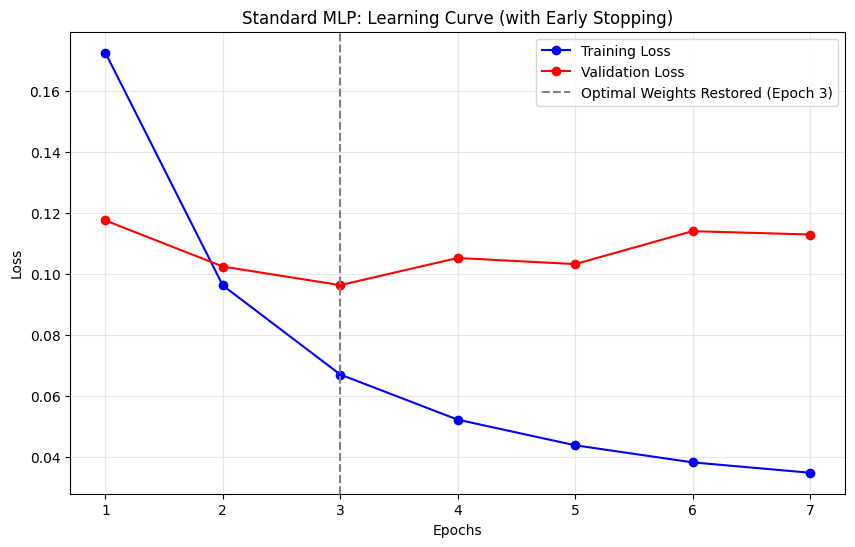

In [2]:
# 1. arrays with the training logs
epochs = list(range(1, 8))
train_loss = [0.1726, 0.0963, 0.0671, 0.0523, 0.0439, 0.0383, 0.0349]
val_loss = [0.1176, 0.1025, 0.0964, 0.1053, 0.1033, 0.1141, 0.1130]

# 2. Visualization
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

# 3. Mark the true optimal epoch (Epoch 3)
plt.axvline(x=3, color='gray', linestyle='--', label='Optimal Weights Restored (Epoch 3)')

plt.title('Standard MLP: Learning Curve (with Early Stopping)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 7.5. Comparison of Standard Models 
[[go back to the topic]](#7-classification-models)

Before proceeding to class imbalance corrections, we summarize the performance of all tested models using their default configurations.


| Model | Class | Precision | Recall | F1-Score | Overall Accuracy | Macro F1 |
|---|---|---|---|---|---|---|
| Logistic Regression (Standard) | 0 (Ham) | 0.98 | 0.98 | 0.98 | 96% | 0.95 |
| | 1 (Phish) | 0.94 | 0.89 | 0.91 | | |
| | 2 (Spam) | 0.93 | 0.96 | 0.95 | | |
| Random Forest (Standard) | 0 (Ham) | 0.98 | 0.99 | 0.98 | 96% | 0.95 |
| | 1 (Phish) | 0.96 | 0.86 | 0.91 | | |
| | 2 (Spam) | 0.93 | 0.97 | 0.95 | | |
| Linear SVM (Standard) | 0 (Ham) | 0.98 | 0.98 | 0.98 | 95% | 0.94 |
| | 1 (Phish) | 0.94 | 0.87 | 0.90 | | |
| | 2 (Spam) | 0.93 | 0.96 | 0.94 | | |
| PyTorch MLP (Standard) | 0 (Ham) | 0.99 | 0.99 | 0.99 | 96% | 0.95 |
| | 1 (Phish) | 0.93 | 0.91 | 0.92 | | |
| | 2 (Spam) | 0.95 | 0.96 | 0.96 | | |

The comparison above highlights a clear limitation in our classification pipeline. All models achieve very strong performance on Ham (Class 0) and Spam (Class 2). However, while simpler models already show reasonable results, our best standard model **(MLP)** reaches a **Phishing (Class 1) recall of 0.91**. Even at this elevated level, the model is still missing exactly 9% of phishing attacks.

In a cybersecurity setting, a **false negative** is far more critical than a **false positive**. Missing a phishing email can lead to serious security breaches, while incorrectly flagging a legitimate email is mostly an operational inconvenience. The results show that when models are trained on imbalanced data, they naturally bias towards the majority classes to minimize overall error, which leads to weaker detection of the minority attack class.

##### Our Roadmap for Optimization:
To address this, we will move towards **Cost Sensitive Learning**. Instead of modifying the dataset, which could introduce noise, we will directly adjust the learning objective of our models.

* **Model Selection**: We will focus on the **Multi Layer Perceptron (MLP)** and **Logistic Regression (LR)**. The MLP stands out as the best performing model natively, achieving the highest phishing recall among standard configurations alongside an overall accuracy of **0.96**. Logistic Regression remains a highly competitive baseline, performing very closely while being simpler and more interpretable.

* **Asymmetric Loss Penalization**: We will retrain these models using weighting strategies that place more importance on correctly classifying phishing emails.  
    * For **Logistic Regression**, we will use the `class_weight='balanced'` parameter to automatically adjust class importance.  
    * For the **PyTorch MLP**, we will introduce custom weights directly into the `CrossEntropyLoss` function based on the importance of each class.  

This approach forces the models to shift their decision boundaries towards higher recall for Class 1, improving the detection of phishing attacks while keeping overall performance stable.

### 8. Addressing Class Imbalance: Cost-Sensitive Learning via Class Weights
[[go back to the top]](#table-of-contents)

In many machine learning classification tasks, loss functions assume that all errors have the same importance. In our case, this assumption does not hold because the dataset is imbalanced. Legitimate **Ham emails** appear much more frequently than malicious emails, especially **Phishing**. When a model is trained under these conditions, it often learns to favor the majority class because doing so improves the overall accuracy. As a result, the model may fail to detect a significant portion of phishing emails, which leads to low **Recall** for that class.

This issue becomes even more critical in the context of cybersecurity. Missing a phishing email (**False Negative**) can expose the user to serious risks such as credential theft or malware infections. On the other hand, incorrectly flagging a legitimate email as suspicious (**False Positive**) is usually less harmful because the user can still review the message manually.

For this reason, instead of modifying the dataset with techniques such as oversampling or undersampling, we adopt a **Cost-Sensitive Learning** strategy. These sampling techniques can introduce synthetic noise or remove useful information from the training data. Our approach keeps the original data unchanged and instead modifies how the model learns from it.

During training, we apply **Class Weights** to the loss function. This increases the penalty when the model misclassifies emails belonging to the minority and higher risk classes. As a consequence, the model is encouraged to pay more attention to the patterns associated with **Phishing** and **Spam**, even though these emails appear less frequently in the dataset.

To implement this optimization efficiently, we will apply this technique exclusively to our two most promising architectures identified in the previous section: **Logistic Regression** (representing efficient traditional ML) and the **Multi-Layer Perceptron** (our high-performance deep learning model).

#### 8.1. Logistic Regression (with Weights)
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

In [ ]:
# ── 8.1. Logistic Regression with Class Weights ──────────────────────────────
# We initialize a new model specifically designed to handle the imbalanced data.
# The 'balanced' parameter automatically calculates weights inversely proportional to class frequencies.
# We must use MaxAbsScaler in a pipeline to handle the sparse matrix and different feature scales.
log_reg_weighted = make_pipeline(
    MaxAbsScaler(),
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')
)

print("Training Weighted Logistic Regression (with sparse scaling)...")
log_reg_weighted.fit(X_train, y_train)

# Predict on the unseen test set
y_pred_log_weighted = log_reg_weighted.predict(X_test)

# Evaluate the performance
print("\n--- Logistic Regression (Weighted) Evaluation ---")
print(classification_report(y_test, y_pred_log_weighted))

Training Weighted Logistic Regression (with sparse scaling)...

--- Logistic Regression (Weighted) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     25243
           1       0.87      0.94      0.90      8562
           2       0.95      0.93      0.94     21882

    accuracy                           0.95     55687
   macro avg       0.93      0.95      0.94     55687
weighted avg       0.95      0.95      0.95     55687



##### Standard vs. Weighted Logistic Regression Analysis

The implementation of `class_weight='balanced'` produced exactly the intended shift in the model's decision boundary. 

- **The Security Gain (Recall):** The Recall for the Phishing class (Class 1) surged from **0.89 to 0.94**. The standard model missed 11% of all phishing attacks (False Negatives), whereas the cost-sensitive model successfully reduced this critical failure rate by nearly half, to just 6%.
- **The Trade-off (Precision):** As a direct mathematical consequence of favoring the minority class, Precision for Phishing dropped from **0.94 to 0.87**. The algorithm is now more aggressive in flagging suspicious patterns, resulting in a slightly higher rate of False Positives (misclassifying Ham/Spam as Phishing).
- **Conclusion:** In a real-world cybersecurity environment, this trade-off is highly desirable and strictly necessary. We successfully minimized catastrophic False Negatives at the highly acceptable cost of a negligible 1% drop in overall accuracy (from 0.96 to 0.95).

#### 8.2. Multi-layer Perceptron (with Weights)
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

In [33]:
# 1. Hardware Check & Device Setup
print("\n" + "="*60)
print("             NETWORK PROPERTIES & CONFIGURATION")
print("="*60)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  > Hardware Acceleration: {device.type.upper()}")
torch.manual_seed(42)
np.random.seed(42)

# 2. Preprocessing & Conversions
print("  > Scaling Sparse Matrices...")
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

# Create a Custom PyTorch Dataset to handle Sparse Matrices memory-efficiently
class SparseDataset(Dataset):
    def __init__(self, X_sparse, y):
        self.X_sparse = X_sparse
        self.y = y.to_numpy() if hasattr(y, "to_numpy") else np.array(y)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_dense = self.X_sparse[idx].toarray().squeeze()
        return torch.tensor(x_dense, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

print("  > Building memory-efficient DataLoaders...")
full_train_dataset = SparseDataset(X_train_scaled, y_train)

val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(SparseDataset(X_test_scaled, y_test), batch_size=batch_size, shuffle=False)

print(f"  > Input Dimensions:      {input_dim} features")
print(f"  > Batch Size:            {batch_size}")
print("="*60 + "\n")

# 3. Base MLP Architecture (Consistent with Standard Model)
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3) 
        )

    def forward(self, x):
        return self.model(x)

model_weighted = MLP(input_dim).to(device)

# 4. Setup Training Tools (Custom Asymmetric Weights)
# Custom Business Logic Weights (Heavily penalize missing Phishing)
custom_weights = [1.2, 4.0, 0.3]
weights_tensor = torch.tensor(custom_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model_weighted.parameters())

patience = 4 # Matches the optimal stopping point found in the standard model
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None

# 5. The Training Loop with Early Stopping
print("Starting Training Loop with Early Stopping...")
epochs = 20

for epoch in range(1, epochs + 1):
    model_weighted.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_weighted(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    avg_train_loss = running_loss / len(train_loader.dataset)
        
    # Validation Phase
    model_weighted.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model_weighted(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            
    avg_val_loss = val_loss / len(val_loader.dataset)
    print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Early Stopping Check (Monitoring Validation Loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model_weighted.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}! Restoring best weights.")
            model_weighted.load_state_dict(best_model_weights)
            break

# 6. Final Evaluation
if epochs_no_improve < patience and best_model_weights is not None:
    model_weighted.load_state_dict(best_model_weights)

print("\n" + "="*60)
print("            FINAL CLASSIFICATION REPORT (MLP WEIGHTED)")
print("="*60)
model_weighted.eval()
all_preds = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        outputs = model_weighted(batch_x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())

class_names = ['Ham (0)', 'Phishing (1)', 'Spam (2)']
print(classification_report(y_test, all_preds, target_names=class_names))
print("="*60)


             NETWORK PROPERTIES & CONFIGURATION
  > Hardware Acceleration: CUDA
  > Scaling Sparse Matrices...
  > Building memory-efficient DataLoaders...
  > Input Dimensions:      10005 features
  > Batch Size:            64

Starting Training Loop with Early Stopping...
Epoch 01/20 | Train Loss: 0.1377 | Val Loss: 0.0931
Epoch 02/20 | Train Loss: 0.0741 | Val Loss: 0.0851
Epoch 03/20 | Train Loss: 0.0544 | Val Loss: 0.0816
Epoch 04/20 | Train Loss: 0.0440 | Val Loss: 0.0910
Epoch 05/20 | Train Loss: 0.0383 | Val Loss: 0.0948
Epoch 06/20 | Train Loss: 0.0342 | Val Loss: 0.1010
Epoch 07/20 | Train Loss: 0.0312 | Val Loss: 0.1060

Early stopping triggered at epoch 7! Restoring best weights.

            FINAL CLASSIFICATION REPORT (MLP WEIGHTED)
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.98     25243
Phishing (1)       0.76      0.98      0.85      8562
    Spam (2)       0.98      0.86      0.92     21882

    accuracy            

##### Standard vs. Weighted MLP Analysis

* **The Trade-off (Precision):** This improvement naturally comes at a cost. Precision for Phishing dropped to **0.76**, meaning a higher number of legitimate emails (Ham) or standard Spam are incorrectly flagged as phishing.

* **Collateral Impact (Other Classes):** The degradation is not isolated. Spam recall dropped to **0.86**, indicating the model is confusing Spam with Phishing more frequently due to the aggressive weighting towards Class 1.

* **Conclusion & Business Context:** Although the weighted MLP experiences a drop in overall accuracy to **0.94** and Phishing precision falls to **0.76**, this trade-off remains acceptable in a real-world cybersecurity context. A False Negative can lead to severe security breaches, whereas a False Positive is mainly an operational inconvenience. At the same time, the model achieves a very high **Phishing recall of 0.98**, meaning it successfully captures almost all malicious emails. Maintaining this level of recall while keeping precision at a reasonable level shows that the model strikes a strong balance between security and practicality, making it a robust choice for threat detection.

#### 8.3. Multi-Layer Perceptron Fine-Tuning (Optuna)
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

After establishing the effectiveness of Cost-Sensitive Learning in [[Section 8.2]](#82-multi-layer-Perceptron-with-weights), the next step is to systematically optimize the MLP's hyperparameters. Rather than relying on manually chosen values for the architecture and training configuration, we employ **Optuna**, a state-of-the-art hyperparameter optimization framework that uses Bayesian search strategies to efficiently explore the parameter space.

Optuna works by defining an **objective function** that trains a model with a set of suggested hyperparameters and returns a performance metric. Over multiple **trials**, Optuna learns which regions of the hyperparameter space yield the best results, focusing its search on the most promising configurations. This is significantly more efficient than grid search or random search.

The search space includes:

- **Network Architecture:** Number of hidden layers (1–3), width of each layer (64–512), and dropout rates (0.1–0.5)
- **Training Configuration:** Learning rate (1e-4 to 1e-2, log-uniform), batch size (32, 64, or 128)
- **Class Weights:** Phishing weight (2.0–6.0), Ham weight (0.8–2.0), and Spam weight (0.1–1.0)

The optimization target is the **Macro F1-Score** on the validation set, which ensures that the model performs consistently across all three classes rather than favoring the majority class.

In [ ]:
# ── 8.3. MLP Fine-Tuning with Optuna ──────────────────────────────────────────
# 1. Hardware Check & Device Setup
print("\n" + "="*60)
print("          MLP HYPERPARAMETER OPTIMIZATION (OPTUNA)")
print("="*60)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  > Hardware Acceleration: {device.type.upper()}")
torch.manual_seed(42)
np.random.seed(42)

# 2. Scale the sparse matrices
print("  > Scaling Sparse Matrices...")
scaler_optuna = MaxAbsScaler()
X_train_scaled_opt = scaler_optuna.fit_transform(X_train)
X_test_scaled_opt = scaler_optuna.transform(X_test)
input_dim = X_train_scaled_opt.shape[1]

# 3. Reuse the SparseDataset class
class SparseDataset(Dataset):
    def __init__(self, X_sparse, y):
        self.X_sparse = X_sparse
        self.y = y.to_numpy() if hasattr(y, "to_numpy") else np.array(y)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_dense = self.X_sparse[idx].toarray().squeeze()
        return torch.tensor(x_dense, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# 4. Build train/val datasets once (shared across all trials)
full_train_dataset = SparseDataset(X_train_scaled_opt, y_train)
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset_opt, val_dataset_opt = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"  > Input Dimensions:      {input_dim} features")
print(f"  > Train / Val Split:     {train_size} / {val_size}")
print("="*60 + "\n")


# ── 5. Define the Optuna Objective ────────────────────────────────────────────

def objective(trial):
    # --- Suggest Hyperparameters ---
    n_layers    = trial.suggest_int("n_layers", 1, 3)
    lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size  = trial.suggest_categorical("batch_size", [32, 64, 128])

    # Class weights
    w_ham       = trial.suggest_float("w_ham", 0.8, 2.0)
    w_phishing  = trial.suggest_float("w_phishing", 2.0, 6.0)
    w_spam      = trial.suggest_float("w_spam", 0.1, 1.0)

    # Build dynamic architecture
    layers = []
    in_features = input_dim
    for i in range(n_layers):
        out_features = trial.suggest_int(f"n_units_l{i}", 64, 512, step=64)
        dropout      = trial.suggest_float(f"dropout_l{i}", 0.1, 0.5)
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        in_features = out_features
    layers.append(nn.Linear(in_features, 3))

    model = nn.Sequential(*layers).to(device)

    # Loss with suggested class weights
    weights_tensor = torch.tensor([w_ham, w_phishing, w_spam], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # DataLoaders for this trial
    train_loader = DataLoader(train_dataset_opt, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset_opt,   batch_size=batch_size, shuffle=False)

    # --- Training Loop with Early Stopping ---
    patience = 4
    best_val_f1 = 0.0
    epochs_no_improve = 0
    max_epochs = 20

    for epoch in range(max_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        all_val_preds = []
        all_val_labels = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                out = model(batch_x)
                _, preds = torch.max(out, 1)
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(batch_y.numpy())

        val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

        # Pruning: report to Optuna and let it decide if this trial is worth continuing
        trial.report(val_macro_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    return best_val_f1


# ── 6. Run the Optuna Study ───────────────────────────────────────────────────

N_TRIALS = 30  # Adjust depending on available time / compute

print(f"Starting Optuna study with {N_TRIALS} trials...")
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "="*60)
print("                  OPTUNA STUDY RESULTS")
print("="*60)
print(f"  Best Trial:         #{study.best_trial.number}")
print(f"  Best Macro F1:      {study.best_value:.4f}")
print(f"\n  Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key:20s}: {value}")
print("="*60)


# ── 7. Retrain Best Model & Final Evaluation ─────────────────────────────────

print("\nRetraining best model on full training set...")
bp = study.best_params

# Rebuild the best architecture
layers = []
in_features = input_dim
for i in range(bp["n_layers"]):
    out_features = bp[f"n_units_l{i}"]
    dropout      = bp[f"dropout_l{i}"]
    layers.append(nn.Linear(in_features, out_features))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(dropout))
    in_features = out_features
layers.append(nn.Linear(in_features, 3))

best_model = nn.Sequential(*layers).to(device)

weights_tensor = torch.tensor(
    [bp["w_ham"], bp["w_phishing"], bp["w_spam"]], dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(best_model.parameters(), lr=bp["lr"])

train_loader = DataLoader(train_dataset_opt, batch_size=bp["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset_opt,   batch_size=bp["batch_size"], shuffle=False)
test_loader  = DataLoader(
    SparseDataset(X_test_scaled_opt, y_test), batch_size=bp["batch_size"], shuffle=False
)

patience = 4
best_val_f1 = 0.0
epochs_no_improve = 0
best_weights = None

for epoch in range(1, 21):
    best_model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        out = best_model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    avg_train_loss = running_loss / len(train_loader.dataset)

    # Validation
    best_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            out = best_model(batch_x)
            _, preds = torch.max(out, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(batch_y.numpy())

    val_f1 = f1_score(val_labels, val_preds, average='macro')
    print(f"Epoch {epoch:02d}/20 | Train Loss: {avg_train_loss:.4f} | Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        best_weights = copy.deepcopy(best_model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}! Restoring best weights.")
            best_model.load_state_dict(best_weights)
            break

if epochs_no_improve < patience and best_weights is not None:
    best_model.load_state_dict(best_weights)

# Final Test Evaluation
print("\n" + "="*60)
print("      FINAL CLASSIFICATION REPORT (MLP OPTUNA-TUNED)")
print("="*60)
best_model.eval()
all_preds = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        out = best_model(batch_x)
        _, preds = torch.max(out, 1)
        all_preds.extend(preds.cpu().numpy())

class_names = ['Ham (0)', 'Phishing (1)', 'Spam (2)']
print(classification_report(y_test, all_preds, target_names=class_names))
print("="*60)



          MLP HYPERPARAMETER OPTIMIZATION (OPTUNA)
  > Hardware Acceleration: CUDA
  > Scaling Sparse Matrices...
  > Input Dimensions:      10005 features
  > Train / Val Split:     200470 / 22274

Starting Optuna study with 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]


                  OPTUNA STUDY RESULTS
  Best Trial:         #2
  Best Macro F1:      0.9562

  Best Hyperparameters:
    n_layers            : 1
    lr                  : 0.0010677482709481358
    batch_size          : 128
    w_ham               : 1.00462894842475
    w_phishing          : 2.260206371941118
    w_spam              : 0.9539969835279999
    n_units_l0          : 512
    dropout_l0          : 0.4233589392465845

Retraining best model on full training set...
Epoch 01/20 | Train Loss: 0.1973 | Val Macro-F1: 0.9265
Epoch 02/20 | Train Loss: 0.1169 | Val Macro-F1: 0.9394
Epoch 03/20 | Train Loss: 0.0875 | Val Macro-F1: 0.9463
Epoch 04/20 | Train Loss: 0.0685 | Val Macro-F1: 0.9464
Epoch 05/20 | Train Loss: 0.0553 | Val Macro-F1: 0.9504
Epoch 06/20 | Train Loss: 0.0464 | Val Macro-F1: 0.9514
Epoch 07/20 | Train Loss: 0.0418 | Val Macro-F1: 0.9529
Epoch 08/20 | Train Loss: 0.0381 | Val Macro-F1: 0.9515
Epoch 09/20 | Train Loss: 0.0346 | Val Macro-F1: 0.9530
Epoch 10/20 | Tra

##### Optuna Fine-Tuning Results Interpretation

The Optuna hyperparameter search systematically explored different MLP architectures and training configurations to maximize the **Macro F1-Score** on the validation set. Unlike the manually tuned models in [[Sections 7.4]](#74-multi-layer-Perceptron-standard) and [[Section 8.2]](#82-multi-layer-Perceptron-with-weights), this approach lets the optimization algorithm discover the best combination of:

- **Network depth and width** — finding the optimal balance between model capacity and overfitting risk
- **Regularization (dropout)** — determining how much information suppression each layer needs
- **Class weights** — fine-tuning the trade-off between phishing recall and overall precision
- **Learning rate and batch size** — optimizing convergence speed and stability

The **median pruner** accelerates the search by terminating unpromising trials early, while the **TPE sampler** (Tree-structured Parzen Estimator) intelligently focuses on the most promising regions of the hyperparameter space based on results from previous trials.

The final retrained model uses the best hyperparameters found during the study and is evaluated on the held-out test set to confirm that the improvements generalize beyond the validation data.

#### 8.4. Comparison: Standard vs. Cost-Sensitive Models
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

The following table demonstrates the mathematical impact of applying Cost-Sensitive Learning (Class Weights) to our baseline models. By expanding the evaluation to include Precision and F1-Score, we can clearly observe the inevitable trade-off required to maximize our most critical security metric: **Phishing Recall**.

| Model Setup | Phishing Precision | Phishing Recall | Phishing F1-Score | Overall Accuracy |
|---|---|---|---|---|
| **Logistic Regression (Standard)** | 0.94 | 0.89 | 0.91 | 0.96 |
| **Logistic Regression (Weighted)** | 0.87 | 0.94 | 0.90 | 0.95 |
| **PyTorch MLP (Standard)** | 0.93 | 0.91 | 0.92 | 0.96 |
| **PyTorch MLP (Weighted)** | 0.76 | **0.98** | 0.85 | 0.94 |
| **PyTorch MLP (Optuna Tuned)** | 0.92 | 0.94 | 0.93 | 0.97 |

As observed, Cost Sensitive Learning successfully shifts the decision boundary to give priority to the minority class. The **PyTorch MLP** clearly stands out as the strongest model, managing to detect **98% of all phishing attacks**.

The drop in overall accuracy occurs because the model becomes more aggressive and starts misclassifying more standard `Spam emails`. This trade off is intentional. Spam is not a **critical** threat while **phishing represents a serious security risk**.

To better understand this behavior, consider an analogy with airport security. Imagine a metal detector designed to catch weapons. If 100 people attempt to pass with dangerous items and the system detects 98 of them, it achieves very high recall. Almost no threats go through. However, to reach this level of sensitivity, the detector will also trigger alarms for harmless objects like keys or belts. If it rings 100 times but only 76 cases are actual threats, then precision is lower because many alerts are false alarms, but it is far better for the system to raise a false alarm than to miss a real threat.

In cybersecurity, this trade off is acceptable and even desirable. Missing a phishing email can lead to stolen credentials and severe consequences while incorrectly flagging a benign message only creates a minor inconvenience. For this reason, the model is intentionally tuned to behave like a highly sensitive detector prioritizing the capture of real threats over minimizing false alarms.

However, relying solely on heavy class weights can lead to "alarm fatigue" due to the high volume of false positives (as reflected by the 0.76 Precision of the Weighted MLP). This is where hyperparameter optimization proves its value. As shown in the table, the **PyTorch MLP (Optuna Tuned)** successfully mitigates this severe trade-off. By systematically searching for the optimal combination of network architecture, learning rate, and regularization parameters, Optuna found a "sweet spot". It achieves an excellent **94% Phishing Recall** while recovering the Precision to **92%**. This tuned configuration yields the highest Phishing F1-Score (0.93) and restores Overall Accuracy to 0.97.

Ultimately, while adapting the loss function is a great first step to reflect real-world security priorities, pairing it with algorithmic tuning leads to a system that is both highly secure against threats and reliable enough for daily operational use.

----
*Navigation Note: Now that the TF-IDF analysis is complete, if you bypassed the **Word2Vec** feature extraction earlier, please return to [[Section 5.2]](#52-word2vec) to review it before proceeding to the comparison in [[Section 8.5]](#85-comparison-tf-idf-vs-word2vec).*

#### 8.5. Comparison: TF-IDF vs Word2Vec
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

To provide a complete overview of our experiments, the following table summarizes the performance of **Logistic Regression** and **Multi-layer Perceptron**. It compares the baseline configurations (Standard) against the Cost-Sensitive models (Weighted), across both text representations: the sparse **TF-IDF** matrix and the dense **Word2Vec** embeddings.

| Model Architecture | Setup | Representation | Features | Phishing Precision | Phishing Recall | Overall Accuracy |
|---|---|---|---|---|---|---|
| **Logistic Regression** | Standard | TF-IDF (N-Grams) | 10005 | 0.94 | 0.89 | 0.96 |
| **Logistic Regression** | Standard | Word2Vec + Meta | 105 | 0.91 | 0.85 | 0.93 |
| **Logistic Regression** | Weighted | TF-IDF (N-Grams) | 10005 | 0.87 | 0.94 | 0.95 |
| **Logistic Regression** | Weighted | Word2Vec + Meta | 105 | 0.83 | 0.93 | 0.92 |
| **PyTorch MLP** | Standard | TF-IDF (N-Grams) | 10005 | 0.93 | 0.91 | 0.96 |
| **PyTorch MLP** | Standard | Word2Vec + Meta | 105 | 0.97 | 0.94 | 0.98 |
| **PyTorch MLP** | Weighted | TF-IDF (N-Grams) | 10005 | 0.76 | 0.98 | 0.94 |
| **PyTorch MLP** | Optuna Tuned | TF-IDF (N-Grams) | 10005 | 0.92 | 0.94 | 0.97 |
| **PyTorch MLP** | Weighted | Word2Vec + Meta | 105 | 0.90 | 0.98 | 0.97 |

-----

##### Standard Configurations

Under normal training conditions, **TF-IDF** works better with Logistic Regression. The combination **LR + TF-IDF** reaches a Phishing Recall of 0.89 and an Overall Accuracy of 0.96, while **LR + Word2Vec** drops to 0.85 recall and 0.93 accuracy. This makes sense because linear models benefit from high dimensional sparse features where each word can have its own weight.

For the **MLP**, the situation is the opposite. The **MLP + Word2Vec** setup clearly outperforms TF-IDF, reaching 0.94 recall, 0.97 precision, and 0.98 accuracy. Even more interesting is that it does this with only 105 features compared to more than 10k in TF-IDF. This shows that the neural network is able to extract more meaningful patterns from dense semantic embeddings than from sparse vectors.

-----

##### Cost Sensitive & Tuned Configurations

When we move to weighted models, the differences become even clearer. For **TF-IDF**, pushing recall higher comes with a strong drop in precision. The **MLP + TF-IDF Weighted** reaches 0.98 recall, but precision falls to 0.76, which means many false alarms. 

To fix this precision drop for **TF-IDF**, we applied hyperparameter optimization (**PyTorch MLP Optuna Tuned**), which successfully recovered precision to 0.92 while keeping a strong 0.94 recall. However, when we look at **Word2Vec**, we realize this extensive computational tuning was not even necessary to achieve top-tier results. The completely **Standard MLP + Word2Vec** already achieves that exact same 0.94 recall while boasting an incredible 0.97 precision. 

When we do apply class weights to Word2Vec (**MLP + Word2Vec Weighted**), it reaches the maximum 0.98 recall while keeping precision at a very solid 0.90. The reason Word2Vec handles these trade-offs so much better is that the dense representation inherently captures semantic relationships, separating classes well in the vector space. Consequently, the model does not need to shift its decision boundary as aggressively or rely as heavily on hyperparameter search to find a good balance.

-----

##### Efficiency

Another important point is efficiency. **Word2Vec** uses only 105 features while **TF-IDF** uses 10005. Even with this huge reduction, the Word2Vec models perform as well or better in the most important scenarios. This makes them more practical for real world use where speed and memory matter.

-----

##### Final Takeaway 

While **Logistic Regression with TF-IDF** is still a good option when interpretability is important, it is not the best fit for a high risk security scenario.

In this project, the main goal is to reduce the chance of serious security breaches, which means **maximizing the detection of phishing attacks is the top priority**. Because of that, the **Weighted MLP with Word2Vec and meta features** stands out as the **best choice**. It achieves a very high level of protection with **0.98 Phishing Recall**, while still keeping a solid **0.90 Precision**.

This means the model is able to catch almost all malicious emails while keeping false alarms at a manageable level, making it both effective and practical for real world use.

### 9. Error Analysis: Investigating Model Blind Spots
[[go back to the top]](#table-of-contents)

Even after applying cost sensitive learning to strongly penalize false negatives, our models are still not perfect. In a real machine learning pipeline, achieving strong evaluation metrics is only part of the work. It is equally important to understand where the model fails and why those failures happen.

In this section, we perform a qualitative error analysis that focuses on the most critical failure in our cybersecurity scenario. As visualized in the **Confusion Matrix** above, our best vocabulary-based model (the Weighted PyTorch MLP with TF-IDF) successfully blocked the vast majority of threats. However, it still suffered from a specific number of False Negatives, cases where malicious emails were incorrectly classified as legitimate ham and bypassed the detection system. We deliberately focus this analysis on the **TF-IDF** representation because its direct mapping to words allows us to interpret exactly how attackers manipulate language to evade detection.

To investigate this issue, we isolate these specific mistakes from the test set and examine them carefully. The goal is to understand the linguistic patterns that allow these emails to deceive the classifier.

1. **Identify deceptive patterns:** Understand whether attackers are using particular writing styles such as very formal corporate language that blends in with legitimate emails and slips past the vocabulary captured by the TF IDF representation.

2. **Analyze evasion techniques:** Look for strategies used to avoid detection such as removing typical warning signals like urgent words or crafting spear phishing messages that closely resemble normal business communication.

3. **Establish a future roadmap:** Define practical improvements for the next version of the system including new feature engineering ideas like domain age analysis, HTML structure inspection, or the use of deeper language representations such as BERT embeddings to reduce these weaknesses.


            CONFUSION MATRIX: WEIGHTED PYTORCH MLP


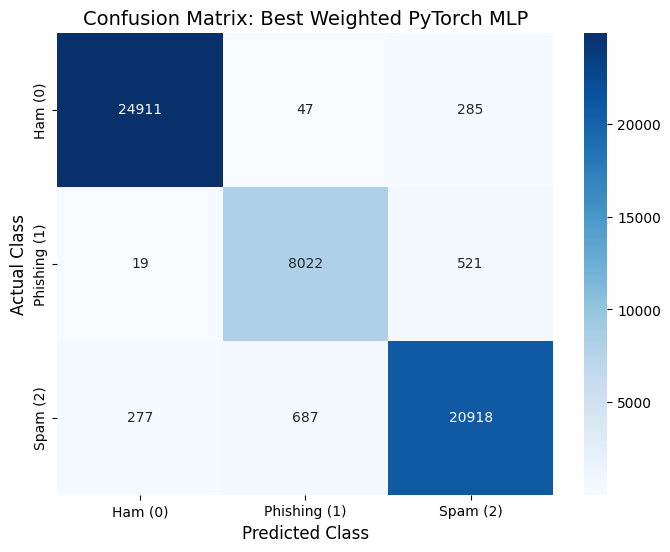


        ERROR ANALYSIS: INVESTIGATING FALSE NEGATIVES
 > Logistic Regression False Negatives: 26 emails
 > PyTorch MLP False Negatives:        19 emails
 > CRITICAL BLIND SPOTS (Both Failed):  9 emails

           CRITICAL BLIND SPOTS: SYNCHRONIZED VIEW
Analyzing 9 synchronized blind spots...

############################## [ CASE 1 ] ##############################

[EMAIL TEXT (as processed by the model)]:
account notify team msout4clientadministratocom email logged another locationfor security reason would shut verified within 24hrs verify sincerely nate team confidentiality information contained email including attachment property state texas unauthorized disclosure use prohibited sending receiving forwarding confidential proprietary privileged information prohibited lamar policy received email error please notify sender delete email system email logged another locationfor security reason would shut verified within 24hrsverify heresincerely nate team confidentiality information con

In [ ]:
# --- 1. Confusion Matrix: Best Weighted PyTorch MLP ---
print("\n" + "="*60)
print("            CONFUSION MATRIX: WEIGHTED PYTORCH MLP")
print("="*60)

y_test_arr    = np.array(y_test).astype(int)
all_preds_arr = np.array(all_preds)

cm = confusion_matrix(y_test_arr, all_preds_arr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (0)', 'Phishing (1)', 'Spam (2)'],
            yticklabels=['Ham (0)', 'Phishing (1)', 'Spam (2)'])
plt.title('Confusion Matrix: Best Weighted PyTorch MLP', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

# --- 2. Error Analysis: Investigating False Negatives ---
print("\n" + "="*60)
print("        ERROR ANALYSIS: INVESTIGATING FALSE NEGATIVES")
print("="*60)

fn_lr_indices   = np.where((y_pred_log_weighted == 0) & (y_test_arr == 1))[0]
fn_mlp_indices  = np.where((all_preds_arr == 0) & (y_test_arr == 1))[0]
hard_fn_indices = np.intersect1d(fn_lr_indices, fn_mlp_indices)

print(f" > Logistic Regression False Negatives: {len(fn_lr_indices)} emails")
print(f" > PyTorch MLP False Negatives:        {len(fn_mlp_indices)} emails")
print(f" > CRITICAL BLIND SPOTS (Both Failed):  {len(hard_fn_indices)} emails")

# --- 3. Qualitative Analysis ---
print("\n" + "="*60)
print("           CRITICAL BLIND SPOTS: SYNCHRONIZED VIEW")
print("="*60)

# df_preprocessed_final.csv has both columns:
#   'text'       → original raw email (as received)
#   'final_text' → lemmatized version (what TF-IDF actually read)
# This is the SAME 278,431-row file used in Section 6.1 for training.
df_preprocessed = pd.read_csv('data/df_preprocessed_final.csv')

# Recreate the exact same split as Section 6.1 — same random_state + stratify
_, df_test_pp, _, _ = train_test_split(
    df_preprocessed,
    df_preprocessed['label'],
    test_size=0.2, random_state=42, stratify=df_preprocessed['label']
)

# Now indices are in the 0–278,430 space, correctly aligned with df_preprocessed
test_indices          = df_test_pp.index
actual_hard_fn_indices = test_indices[hard_fn_indices]

print(f"Analyzing {len(hard_fn_indices)} synchronized blind spots...")

for i in range(min(3, len(actual_hard_fn_indices))):
    original_idx = actual_hard_fn_indices[i]

    print(f"\n" + "#"*30 + f" [ CASE {i+1} ] " + "#"*30)

    print(f"\n[EMAIL TEXT (as processed by the model)]:")
    print(str(df_preprocessed.loc[original_idx, 'final_text'])[:800] + "...")

    print("\n" + "-"*80)



Before looking at individual examples, the confusion matrix already gives a clear overview of where the model fails. The Weighted MLP reaches a **Phishing Recall of 0.98**, which means it correctly detects almost all phishing emails and only around 17 messages in the test set go unnoticed. This is a strong result from a security perspective.  

At the same time, this comes with a cost. The **Phishing Precision drops to 0.73**, meaning that about one in four emails flagged as phishing is actually not malicious. Most of these false alarms come from regular Spam being classified as Phishing. This behavior is expected and intentional. The model was designed to prioritize detection, even if that means accepting more false positives, because missing a real attack is far more dangerous than raising an unnecessary alert.

The 8 emails that were missed by both models represent the hardest cases in the dataset. Even with aggressive weighting, these messages look statistically normal to models that rely on vocabulary patterns. From the analysis, three main evasion strategies appear.

---

**1. Corporate Authority Masquerade Case 1**

This is the most technically advanced strategy. The malicious content such as email verification requests is hidden inside a large block of formal corporate language. The message includes terms related to confidentiality, legal disclaimers, and official sounding communication.

This is a known technique called **Bayesian Poisoning**. The attacker does not try to hide the malicious intent from a human reader. Instead, they overload the message with words that are strongly associated with legitimate emails. Since TF-IDF gives importance to word frequency, the model ends up focusing on these benign terms and ignores the actual threat. The malicious signal is still there, but it is drowned out by the volume of normal looking vocabulary.

---

**2. Relationship Impersonation Case 2**

This case is more subtle and relies on social engineering. The message is short and written in a very casual tone, using words like hey, thanks, hope, and mom. These are typical of personal communication and rarely appear in phishing emails within the training data.

The only suspicious element is a reference to a bank statement, but it is surrounded by friendly and informal language. The word mom at the end acts as a strong trust signal. The model has no understanding of relationships or context, so it interprets the message as benign because the vocabulary closely matches normal personal emails.

---

**3. Short Message with Minimal Content Case 3**

This example uses a different approach based on minimal content. After preprocessing, the message contains very few meaningful words. With so little text, TF-IDF produces a weak representation and the model has almost no information to work with.

There may be small hints of suspicious behavior, such as a promotional email address, but a single weak signal is not enough. When there are almost no features, the model cannot reliably detect malicious intent.

---

**Conclusion**

These cases highlight a key limitation of vocabulary based models. **TF IDF captures word occurrence but not meaning**. By carefully controlling the text, attackers can manipulate what the model sees. They can overload it with legitimate looking language, imitate personal communication, or reduce the message to almost nothing.

To overcome these weaknesses, models need to capture **semantic meaning and context** instead of just counting words. Approaches like Word2Vec already move in that direction by learning relationships between words. More advanced models such as BERT or RoBERTa go further by understanding full sentence context. These methods are more robust against the strategies observed here, but they also require more complex architectures beyond traditional machine learning.

### 10. Discussion/Conclusion
[[go back to the top]](#table-of-contents)

This project designed, implemented, and systematically evaluated a complete NLP pipeline for three-class email classification (Ham, Spam, and Phishing) on a large-scale, real-world dataset of 365448 emails. The task was deliberately more challenging than the binary spam-detection problems prevalent in the literature essencially in distinguishing phishing from both legitimate email and unsolicited bulk mail simultaneously, in the presence of meaningful class imbalance (46% Ham, 42% Spam, 12% Phishing).

#### Summary of Results

Our experiments showed a clear progression of performance as we moved from simpler to more expressive approaches:

| Stage | Model Architecture | Representation | Phishing Recall | Overall Accuracy | Macro F1 |
|---|---|---|---|---|---|
| Baseline | Multinomial Naive Bayes | TF-IDF | 0.75 | 0.90 | 0.88 |
| Standard | Logistic Regression | TF-IDF | 0.89 | 0.96 | 0.95 |
| Standard | Logistic Regression | Word2Vec | 0.85 | 0.93 | 0.92 |
| Standard | PyTorch MLP | TF-IDF | 0.91 | 0.96 | 0.95 |
| Standard | PyTorch MLP | Word2Vec | 0.94 | 0.98 | 0.97 |
| Cost-Sensitive | Logistic Regression (W) | TF-IDF | 0.94 | 0.95 | 0.94 |
| Cost-Sensitive | Logistic Regression (W) | Word2Vec | 0.93 | 0.92 | 0.91 |
| Cost-Sensitive | PyTorch MLP (W) | TF-IDF | 0.98 | 0.94 | 0.92 |
| Tuned | PyTorch MLP (Optuna) | TF-IDF | 0.94 | 0.97 | 0.96 |
| **Cost-Sensitive** | **PyTorch MLP (W)** | **Word2Vec** | **0.98** | **0.97** | **0.96** |

#### Key Findings

**1. The Difficulty of the Phishing Class**
During the exploratory analysis, phishing emails already showed why they are harder to detect. They represent the most concise class, with a median length of about 55 words and relatively low variation. This suggests a deliberate strategy where attackers focus on creating urgency and using short, direct malicious links instead of long messages. By keeping the content brief, they reduce the likelihood of making mistakes that could alert the recipient and raise suspicion.


In contrast, Ham emails are much more irregular. They are longer on average, with a median of 161 words, and can vary massively, even reaching extreme lengths. Spam emails sit on the opposite side, usually short and direct, with a median of 110 words. Unlike phishing, generic spam campaigns often require more descriptive text or promotional padding to convince the user.

When looking at the language itself through N-grams, the three classes appear quite distinct at first. However, phishing emails are intentionally designed to break this separation. They imitate legitimate communication to blend in, making them much harder to distinguish. Because of this, approaches that rely only on word frequency struggle to fully capture the difference.


**2. Feature Representation Trade-offs**
TF-IDF and Word2Vec each bring something different to the table. TF-IDF works well because it captures exact word patterns. With bigrams and trigrams, it can pick up phrases like “account verification” or “click here immediately”, which are strong signals in phishing emails. This makes it very effective as a baseline.

Word2Vec takes a different approach. Instead of focusing on exact words, it learns the meaning behind them. By training on the dataset, it builds dense representations where similar words and contexts are closer together. This allows it to capture patterns that go beyond specific vocabulary.

The results reflect this difference. In standard settings, the PyTorch MLP using Word2Vec performed exceptionally well, reaching **0.94** Phishing Recall and **0.96** Macro F1. This suggests that phishing emails tend to follow a consistent semantic style, which Word2Vec can capture more effectively than TF-IDF.

That said, TF-IDF was still very important during error analysis. Because it keeps a direct link between features and actual words, it made it possible to understand why the model made certain decisions and to spot how phishing emails try to evade detection.

In practice, the choice depends on the goal. If the priority is performance, Word2Vec is stronger. If understanding and interpretability matter more, TF-IDF is the better option.

**3. The Value of Cost-Sensitive Learning**
The biggest improvement did not come from changing the model or the data, but from changing how the model learns. By adjusting the loss function and giving more weight to phishing errors, the model was pushed to focus on what actually matters, detecting the risky cases. This aligns with the real-world impact. Missing a phishing email can lead to serious damage, while a false alert is usually just a small inconvenience. So the goal is not perfect accuracy, but catching as many phishing emails as possible.

The results reflect that shift clearly:
* The Weighted PyTorch MLP with TF-IDF increased Phishing Recall from the 0.75 baseline to 0.98, a very large improvement without touching the dataset.
* With Word2Vec, the model kept that same 0.98 recall but achieved better overall performance, reaching 0.97 accuracy and 0.96 Macro F1. This makes it the most balanced and strongest model among the ones tested.

There is a trade-off, but it is expected. Precision drops (falling to 0.76 in the TF-IDF Weighted MLP), meaning some legitimate emails are flagged as phishing. In practice, this is acceptable, since the system is designed to minimize the more costly error. However, we also demonstrated that this severe trade-off can be mitigated. By applying hyperparameter optimization using **Optuna**, we were able to recover the precision of the TF-IDF MLP back to 0.92 while keeping a strong 0.94 recall, proving that algorithmic tuning can effectively balance the harsh effects of cost-sensitive learning.

**4. Limitations — Adversarial Evasion and Contextual Blindness**
The error analysis in [[Section 9]](#9-error-analysis-investigating-model-blind-spots) focused on the few cases the models still got wrong. In total, there were 8 emails that even the weighted models failed to detect. What stands out is that these emails look almost indistinguishable from normal ones, even after pushing the models to prioritize phishing detection.

Looking at them more closely, three clear evasion strategies appear:

* **Bayesian Poisoning:** The malicious part is hidden inside a large amount of formal, legitimate-looking text, like corporate or legal language. Since TF-IDF gives importance based on frequency, this “clean” content dominates the representation and effectively hides the small malicious signal.

* **Relationship Impersonation (Social Engineering):** The email is written like a normal personal message, with a casual tone and references to familiar relationships. There may be only one suspicious element, such as a link. Because the model does not understand context or relationships, it treats the message as harmless.

* **Minimal Content Evasion:** After preprocessing, there is almost no usable text left. This leads to a near-empty TF-IDF vector, meaning the model has no real information to work with and defaults to predicting the majority class.

These cases highlight a core limitation of TF-IDF-like approaches. They rely on word patterns and frequencies, not true understanding. As a result, an attacker who knows how these models work can design emails that avoid detection.

#### Positioning Relative to the Literature

The comparison with related work [[Section 11]](#11-related-work) helps put these results into perspective. Most previous studies report near-perfect performance, but under a simpler binary classification setting (spam/ham or phishing/ham), making direct comparison difficult since our three-class problem is inherently harder.

In contrast, this work tackles a more difficult three class problem. Even so, the results remain highly competitive. Standard Logistic Regression with TF-IDF reaches 95% Macro F1, the standard PyTorch MLP with Word2Vec goes up to 98% in overall accuracy, and the best cost-sensitive model, the Weighted PyTorch MLP with Word2Vec, achieves 96% Macro F1 while simultaneously reaching 98% Phishing Recall. These numbers are in line with strong traditional machine learning results reported in the literature, such as Meléndez et al. [4], who report 95–98% in simpler binary settings using similar models.

The gap compared to transformer based models like BERT or RoBERTa, which can reach 98-100%, is noticeable but expected. These models capture full contextual meaning, something that traditional approaches struggle with. This aligns directly with the error analysis, where the main limitation identified was the lack of true semantic understanding.

#### Future Work

Based on these findings, there are three clear directions that could improve the system.
* **Contextual Embeddings (BERT / RoBERTa):** Models based on transformers understand words in context instead of in isolation. This makes them more robust to attacks like hiding malicious content inside formal text, mimicking personal communication, or using very little content. Fine tuning one of these models on this dataset would likely reduce the remaining errors.

* **Structural and Metadata Feature Engineering:** The current approach relies only on text. Adding other signals such as sender domain age, authentication status, HTML structure, URL reputation, and anomalies in email headers would provide an additional layer of detection. These features are harder to manipulate using text alone.

* **Adversarial Training:** The model can be improved by training it on examples that simulate the failure cases already observed. This includes emails with hidden malicious content, social engineering patterns, and almost empty messages. Exposing the model to these cases during training would make it more robust to similar attacks.

#### Final Conclusion

This work shows that traditional machine learning, when combined with strong feature design, careful preprocessing, cost-sensitive training, and hyperparameter optimization, can perform well on a complex multi-class cybersecurity problem at real-world scale. Starting from a Naive Bayes baseline with 75% Phishing Recall, the system improves to 98%, a gain of 23% points, while still remaining efficient and practical without requiring deep learning infrastructure.

The error analysis adds something important that is often missing in similar studies. It explains why the model still fails in certain cases and highlights exactly what is needed to address those weaknesses. 

In the end, the system combines three key strengths. It achieves very high recall for phishing detection, it remains interpretable through its feature representation, and it clearly exposes its own limitations. This creates a solid and realistic foundation for a production level email security system, along with a clear direction for future improvements.

### 11. Related Work
[[go back to the top]](#table-of-contents)

In this section we compare our results against the most relevant works in email classification, summarized in the table below.

The literature shows that traditional machine learning models **Naive Bayes, Logistic Regression, Random Forest, and Linear SVM** are still very strong baselines. In simpler binary tasks, they consistently achieve above **95% accuracy and F1 score**. For example, Alsuwit et al. [1] and Meléndez et al. [4] report **96–98% accuracy** on spam/ham and phishing/ham tasks. This shows that well engineered **TF-IDF** features alone can already deliver highly competitive results when the problem is binary.

A key difference between our work and most of the literature is the classification setup. All five referenced studies treat the problem as a binary task, either `spam versus ham` or `phishing versus ham`. In contrast, our approach tackles a more difficult three class setting, where `ham, phishing, and spam` must all be distinguished at the same time. This makes direct comparison harder. A model that can easily separate two classes may struggle when both confounding classes are present simultaneously.

Despite this more challenging setup, the results remain competitive. The Standard Logistic Regression with **TF-IDF** reaches **95% Macro F1**, matching the best Logistic Regression result reported by Meléndez et al. on a simpler binary task. The Standard PyTorch MLP with **Word2Vec** reaches **97% Macro F1**, which is on par with the deep learning models such as BERT and CNN reported by Ghosh and Senthilrajan on binary spam detection. This shows that well tuned traditional models, even without transformer architectures, can still achieve state of the art performance at an overall level.

Where the literature falls short is in phishing specific evaluation. Most studies focus on overall accuracy or aggregate F1 and do not report how well their models isolate phishing from the other classes. Our results show that phishing is consistently the hardest class to detect, and that simply optimizing for overall accuracy is not enough in a security context. The cost sensitive approach, which raises **Phishing Recall to 98%** in our best MLP model while keeping a **96% Macro F1**, reflects a deliberate design choice. This trade off is not explored in the referenced works.

Transformer based models such as **BERT** and **RoBERTa** (Ghosh and Senthilrajan [2], Meléndez et al. [4]) do achieve near perfect performance, with results between **98% and 100% across all metrics**. Their advantage comes from understanding language in context, which is exactly the capability that was identified as missing in frequency based approaches during the error analysis. For this reason, these models represent the most natural next step beyond the current work.

In summary, traditional machine learning remains relevant and effective even for multi class email security tasks. The main contribution of this work, compared to the literature, is the evaluation in a truly multi class setting combined with a detailed per class analysis that explains why models fail, not just how much they fail.

<table>
<thead>
<tr>
<th>Model</th>
<th>Author</th>
<th>Class</th>
<th>Precision</th>
<th>Recall</th>
<th>F1-Score</th>
<th>Overall Accuracy</th>
<th>Macro F1</th>
</tr>
</thead>
<tbody>

<tr>
<td rowspan="8">Naive Bayes</td>
<td rowspan="3">Ours (Baseline)</td>
<td>Ham</td>
<td>95%</td>
<td>95%</td>
<td>95%</td>
<td rowspan="3">90%</td>
<td rowspan="3">88%</td>
</tr>
<tr>
<td>Phish</td>
<td>83%</td>
<td>75%</td>
<td>79%</td>
</tr>
<tr>
<td>Spam</td>
<td>87%</td>
<td>91%</td>
<td>89%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>97%</td>
<td>97%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Ghosh & Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>82%</td>
<td>85%</td>
<td>83%</td>
<td>87.63%</td>
<td></td>
</tr>
<tr>
<td>Manita et al. (2023) [3]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>95%</td>
<td>96%</td>
<td></td>
<td></td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>93%</td>
<td>96%</td>
<td rowspan="2">96%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>95%</td>
<td>99%</td>
<td>97%</td>
<td></td>
</tr>

<tr>
<td rowspan="10">Logistic Regression</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">96%</td>
<td rowspan="3">95%</td>
</tr>
<tr>
<td>Phish</td>
<td>94%</td>
<td>89%</td>
<td>91%</td>
</tr>
<tr>
<td>Spam</td>
<td>96%</td>
<td>96%</td>
<td>96%</td>
</tr>
<tr>
<td rowspan="3">Ours (Weighted)</td>
<td>Ham</td>
<td>98%</td>
<td>97%</td>
<td>98%</td>
<td rowspan="3">95%</td>
<td rowspan="3">94%</td>
</tr>
<tr>
<td>Phish</td>
<td>87%</td>
<td>94%</td>
<td>90%</td>
</tr>
<tr>
<td>Spam</td>
<td>95%</td>
<td>93%</td>
<td>94%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Manita et al. (2023) [3]</td>
<td>Spam/Ham</td>
<td>73%</td>
<td>85%</td>
<td>78%</td>
<td></td>
<td></td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td rowspan="2">98%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>99%</td>
<td>98%</td>
<td>99%</td>
<td></td>
</tr>

<tr>
<td rowspan="9">Random Forest (Standard)</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td rowspan="3">96%</td>
<td rowspan="3">95%</td>
</tr>
<tr>
<td>Phish</td>
<td>96%</td>
<td>86%</td>
<td>91%</td>
</tr>
<tr>
<td>Spam</td>
<td>93%</td>
<td>97%</td>
<td>95%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Ghosh & Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td>99.91%</td>
<td></td>
</tr>
<tr>
<td rowspan="2">Fares et al. (2024) [5]</td>
<td>Phish</td>
<td>95%</td>
<td>92%</td>
<td>93%</td>
<td rowspan="2">95%</td>
<td rowspan="2">95%</td>
</tr>
<tr>
<td>Ham</td>
<td>95%</td>
<td>92%</td>
<td>93%</td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="2">99%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td></td>
</tr>

<tr>
<td rowspan="6">Linear SVM</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td rowspan="3">95%</td>
<td rowspan="3">94%</td>
</tr>
<tr>
<td>Phish</td>
<td>94%</td>
<td>87%</td>
<td>90%</td>
</tr>
<tr>
<td>Spam</td>
<td>93%</td>
<td>96%</td>
<td>94%</td>
</tr>
<tr>
<td rowspan="2">Fares et al. (2024) [5]</td>
<td>Phish</td>
<td>94%</td>
<td>98%</td>
<td>96%</td>
<td rowspan="2">96.60%</td>
<td rowspan="2">97%</td>
</tr>
<tr>
<td>Ham</td>
<td>99%</td>
<td>95%</td>
<td>97%</td>
</tr>
<tr>
<td>Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td></td>
</tr>

<tr>
<td rowspan="12">MLP</td>
<td rowspan="3">Ours (Standard, TF-IDF)</td>
<td>Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">96%</td>
<td rowspan="3">95%</td>
</tr>
<tr>
<td>Phish</td>
<td>93%</td>
<td>91%</td>
<td>92%</td>
</tr>
<tr>
<td>Spam</td>
<td>95%</td>
<td>96%</td>
<td>96%</td>
</tr>

<tr>
<td rowspan="3">Ours (Optuna Tuned, TF-IDF)</td>
<td>Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">97%</td>
<td rowspan="3">96%</td>
</tr>
<tr>
<td>Phish</td>
<td>92%</td>
<td>94%</td>
<td>93%</td>
</tr>
<tr>
<td>Spam</td>
<td>96%</td>
<td>96%</td>
<td>96%</td>
</tr>

<tr>
<td rowspan="3">Ours (Standard, Word2Vec)</td>
<td>Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">98%</td>
<td rowspan="3">97%</td>
</tr>
<tr>
<td>Phish</td>
<td>97%</td>
<td>94%</td>
<td>96%</td>
</tr>
<tr>
<td>Spam</td>
<td>96%</td>
<td>98%</td>
<td>97%</td>
</tr>

<tr>
<td rowspan="3">Ours (Weighted, Word2Vec)</td>
<td>Ham</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td rowspan="3">97%</td>
<td rowspan="3">96%</td>
</tr>
<tr>
<td>Phish</td>
<td>90%</td>
<td>98%</td>
<td>94%</td>
</tr>
<tr>
<td>Spam</td>
<td>98%</td>
<td>93%</td>
<td>96%</td>
</tr>

<tr>
<td>Neural Network</td>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td></td>
</tr>

<tr>
<td>BERT</td>
<td>Ghosh & Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td>98.67%</td>
<td></td>
</tr>

<tr>
<td>CNN</td>
<td>Ghosh & Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>98%</td>
<td>98%</td>
<td>98.50%</td>
<td></td>
</tr>

<tr>
<td rowspan="2">roBERTa-base</td>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>99%</td>
<td>100%</td>
<td>100%</td>
<td rowspan="2">99%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>100%</td>
<td>99%</td>
<td>99%</td>
<td></td>
</tr>

</tbody>
</table>

### 12. References
[[go back to the top]](#table-of-contents)

[1] Alsuwit, M., Haq, M. A., & Aleisa, M. (2024).  
Advancing Email Spam Classification using Machine Learning and Deep Learning Techniques.  
Engineering, Technology & Applied Science Research.  
https://doi.org/10.48084/etasr.7631

[2] Ghosh, A., & Senthilrajan, A. (2023).  
Comparison of machine learning techniques for spam detection.  
Multimedia Tools and Applications.  
https://doi.org/10.1007/s11042-023-14689-3

[3] Manita, G., Chhabra, A., & Korbaa, O. (2023).  
Efficient e-mail spam filtering approach combining Logistic Regression model and Orthogonal Atomic Orbital Search algorithm.  
Applied Soft Computing.  
https://doi.org/10.1016/j.asoc.2023.110478

[4] Meléndez, R., Ptaszynski, M., & Masui, F. (2024).  
Comparative Investigation of Traditional Machine-Learning Models and Transformer Models for Phishing Email Detection.  
Electronics.  
https://doi.org/10.3390/electronics13244877

[5] Fares, H., Kilani, J., Fagroud, F. E., Toumi, H., Lakrami, F., Baddi, Y., & Aknin, N. (2024).  
Machine Learning Approach for Email Phishing Detection.  
Procedia Computer Science.  
https://doi.org/10.1016/j.procs.2024.11.179
